In [ ]:
import numpy as np

class ParticleFilter:
    def __init__(self, num_particles, state_dim):
        self.num_particles = num_particles

        self.particles = np.random.uniform(-10, 10, (num_particles, state_dim))

        self.weights = np.ones(num_particles) / num_particles

    def predict(self, motion_model):
        self.particles += motion_model(self.particles)

    def update(self, observation, likelihood_model):
        self.weights *= likelihood_model(self.particles, observation)
        self.weights /= np.sum(self.weights) # Normalize weights

    def resample(self):
        indices = np.random.choice(
        range(self.num_particles), size=self.num_particles, p=self.weights
        )
        self.particles = self.particles[indices]
        self.weights.fill(1.0 / self.num_particles)

# Example usage
pf = ParticleFilter(num_particles=1000, state_dim=2)

# Define motion and likelihood models
motion_model = lambda particles: np.random.normal(0, 1, particles.shape)

likelihood_model = lambda particles, obs: np.exp(-np.linalg.norm(particles - obs, axis=1))

# Simulate one step
pf.predict(motion_model)
pf.update(np.array([2, 3]), likelihood_model)
pf.resample()

In [22]:
pf = ParticleFilter(num_particles=10, state_dim=1)

In [73]:
pf.num_particles + motion_model(pf.particles)

array([[ 9.79757491],
       [ 9.47959332],
       [ 8.48256155],
       [10.73823405],
       [10.12101484],
       [ 8.51449132],
       [11.2502231 ],
       [ 9.92859779],
       [11.26010566],
       [ 8.96393718]])

In [ ]:
#particles have a value

#motion --> p_value = p_value + normal(0,1) #value changes +/-

In [75]:
np.array([2, 3])

array([2, 3])

In [89]:
import numpy as np
import matplotlib.pyplot as plt

#----------------------------
# Simulation parameters
#----------------------------
T = 15 # number of time steps
Q = 1.0 # process noise variance
R = 4.0 # measurement noise variance
N = 200 # number of particles

# True and observed values
x_true = np.zeros(T)
z_meas = np.zeros(T)

# Initialize true state
x_true[0] = 0.0

#----------------------------
# Particle filter initialization
#----------------------------
particles = np.random.normal(0.0, 2.0, N) # prior p(x0) = N(0, 2^2)
weights = np.ones(N) / N

# Storage for state estimates
x_est = np.zeros(T)
x_est[0] = np.average(particles, weights=weights)

#----------------------------
# Main loop
#----------------------------
for k in range(1, T):
    # True system evolution
    eta_k = np.random.normal(0.0, np.sqrt(Q)) # process noise
    v_k = np.random.normal(0.0, np.sqrt(R)) # measurement noise
    x_true[k] = x_true[k-1] + eta_k
    z_meas[k] = x_true[k] + v_k

    #---Prediction step--
    particles += np.random.normal(0.0, np.sqrt(Q), N)

    #---Weighting step--
    likelihoods = np.exp(-0.5 * ((z_meas[k]- particles)**2) / R)
    weights *= likelihoods
    weights += 1.e-300 # avoid round-off to zero
    weights /= np.sum(weights)

    #---Compute effective sample size (ESS)--
    Neff = 1. / np.sum(weights**2)

    #---Resampling step (systematic)--
    if Neff < N / 2:
        # Systematic resampling
        positions = (np.arange(N) + np.random.rand()) / N
        indexes = np.zeros(N, "i")
        cumulative_sum = np.cumsum(weights)
        i, j = 0, 0
        while i < N:
            if positions[i] < cumulative_sum[j]:
                indexes[i] = j
                i += 1
            else:
                j += 1
        particles = particles[indexes]
        weights.fill(1.0 / N)
    #--- State estimation--
    x_est[k] = np.average(particles, weights=weights)

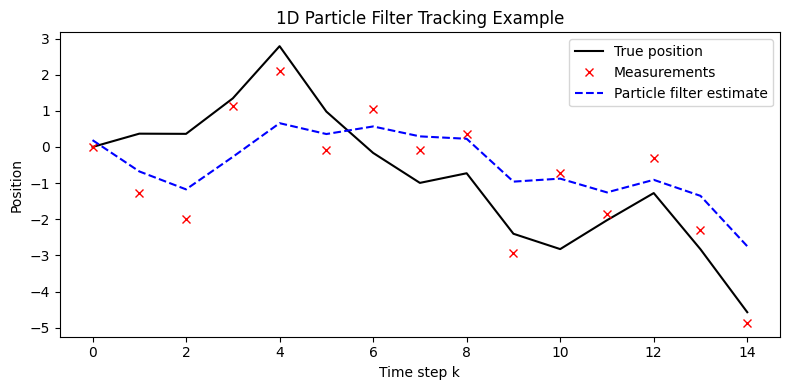

In [90]:
plt.figure(figsize=(8,4))
plt.plot(x_true, "k-", label="True position")
plt.plot(z_meas, "rx", label="Measurements")
plt.plot(x_est, "b--", label="Particle filter estimate")
plt.xlabel("Time step k")
plt.ylabel("Position")
plt.legend()
plt.title("1D Particle Filter Tracking Example")
plt.tight_layout()
plt.show()

In [ ]:
#lab
#1 random all rules change val
#does not make "choice", whatever it guesses, it flawlessly infers the results of the choice


#2random sampled subset changes val
#2.1 subset changes instantly (after each turn)
#2.2 subset changes periodically (after x turns)
#2.3 subset changes dynamically (low ones drop based on threshold)


#3rules are connected (foraging?)
#subset is a group of n possible rules centered around rule x
#A -- rule similarity based on n common features? + 1 for common location "LABEC" +1 for exact feature 
#kind like feature proximity?

#B -- rule similarity based on results? number of matching passed stimuli? -- would somehow require knowing that...? -- meta- something????

#C subset based the more stimuli common in the passed set, the closer the rules are.



#rule-based foraging based on foraging-based rules --> peak as above so below

#3.1 instant subset changes (after the exact rule x is proved wrong) 
#3.1.1 new x chosen randomly
#3.1.2 new x chosen based on weights? (make sure not to get stuck)
#relative peaks? --> read up on observation studies?

#3.2 periodic subset changes
#subset stays for n turns -> more refined local exploration?
#3.2.1 then random
#3.2.2 then by weight

#3.3 movement (dynamic)
# rules below threshold weight are dropped, new ones are sampled from the closest? 


In [ ]:
import random
import itertools
from datasets import Dataset, disable_progress_bars
from rule import *
from plotnine import *
import pandas as pd
from scipy.special import softmax, logit
import pymc as pm
disable_progress_bars()

In [615]:
def make_plots(ag_rules:Dataset):
    n_t = np.array(ag_rules["beta"]).shape[1]
    ##wrangle the data
    df = ag_rules.to_pandas()
    p_cols = pd.DataFrame(df["mp"].to_list(), columns=[i for i in range(n_t)])
    p_cols["rule_id"] = [i for i in range(80)]
    beta_cols = pd.DataFrame(df["beta"].to_list(), columns=[i for i in range(n_t)])
    beta_cols["rule_id"] = [i for i in range(80)]

    df_2 = pd.DataFrame()
    df_2["rule"] = df[["rule"]]
    df_2["rule_id"] = [i for i in range(80)]
    df_probs = df_2.merge(p_cols, on="rule_id").melt(["rule","rule_id"],value_name="prob",var_name="turn")
    df_betas = df_2.merge(beta_cols, on="rule_id").melt(["rule","rule_id"],value_name="beta",var_name="turn")


    #select the first 5 rules every 5th turn for visualizing the whole beta dist change
    df_betas = df_betas[(df_betas["rule_id"] < 5) & (df_betas["turn"]%5==0)].reset_index()
    #sample 100 vals from the betas
    abcols = pd.DataFrame(df_betas["beta"].to_list(), columns=["a","b"])
    df_betas["a"]= abcols["a"]
    df_betas["b"]= abcols["b"]
    draws = [pm.draw(pm.Beta.dist(a,b),100) for a,b in zip(df_betas["a"],df_betas["b"])]
    df_betas["draws"] = draws
    draw_cols = pd.DataFrame(df_betas["draws"].to_list(), columns=[i for i in range(100)])

    df_betas= df_betas[["rule","rule_id","turn","beta","a","b"]].join(draw_cols).melt(["rule","rule_id","turn","beta","a","b"],var_name="draw")
    df_betas["rule_id"] = df_betas["rule_id"].astype(str)

    #select every 5th turn for displaying
    plot1 =(
        ggplot(df_probs[df_probs["turn"]%5==0],aes("rule_id","prob"))
        + geom_point()
        + facet_wrap("turn",ncol=3,scales="free",shrink=False)
        + geom_hline(yintercept =0.5, color = "red")
        + theme_classic()
        + theme(figure_size=(10,10))
        
    )
    plot2=(
    ggplot(df_betas,aes("value",group="rule_id",fill="rule_id"))
           +geom_density(alpha= 0.5)
           +facet_wrap("turn")
           +theme_classic()
    )

    return plot1, plot2

In [ ]:
def rule_maker_3dims():
    """Only creates X and (Y or Z) type rules"""
    #n important features in rule
    n_dims = 3
    # select feature dimensions
    dims = [ ''.join([*a]) for i in range(1,n_dims+1) for a in itertools.combinations('lLaAbBeEcC', i) if len(a)==n_dims]
    dims = [i for i in dims if remove_dup(i) != None]

    #translate properties
    #sample from dims (unif)  -> selects a random combination of the 3 features
    pos_in_dims = random.randint(0,len(dims)-1)
    rule_abr = dims[pos_in_dims]
    rule_trans =translate_rule(rule_abr)

    # find logical connections 
    # scheme is always X and (Y or Z)
    verbal_rule = f"{rule_trans[0]} and ( {rule_trans[1]} or {rule_trans[2]} )"
    #make it formal
    formal_rule = verbal_to_formal(verbal_rule)
    eval_content_check(formal_rule)
    
    return verbal_rule, formal_rule

#add weights to all
def weights(ds,w=0):
    "resset all weights to w"
    ds.update({"w":[w]})
    return ds

def real_rule_pass_based_weights(ds,passed:bool,stim:list[int]):
    """ If rule is in accordance with real one, w +, else w - """
    passes = ds["passes"]

    last_weight = ds["w"][-1]

    if (passed and (stim in passes)) or (not passed and (stim not in passes)):
        ds["w"].append(last_weight+1)
    else:
        ds["w"].append(last_weight-1)
    return ds

def dim_3_filter(ds):
    rule = ds["rule"].split()
    l = len(rule)
    if (l ==7) and (rule[1]=="and" and rule[2] =="(" and rule[4]=="or" and rule[6] == ")"):
        return True
    else:
        return False

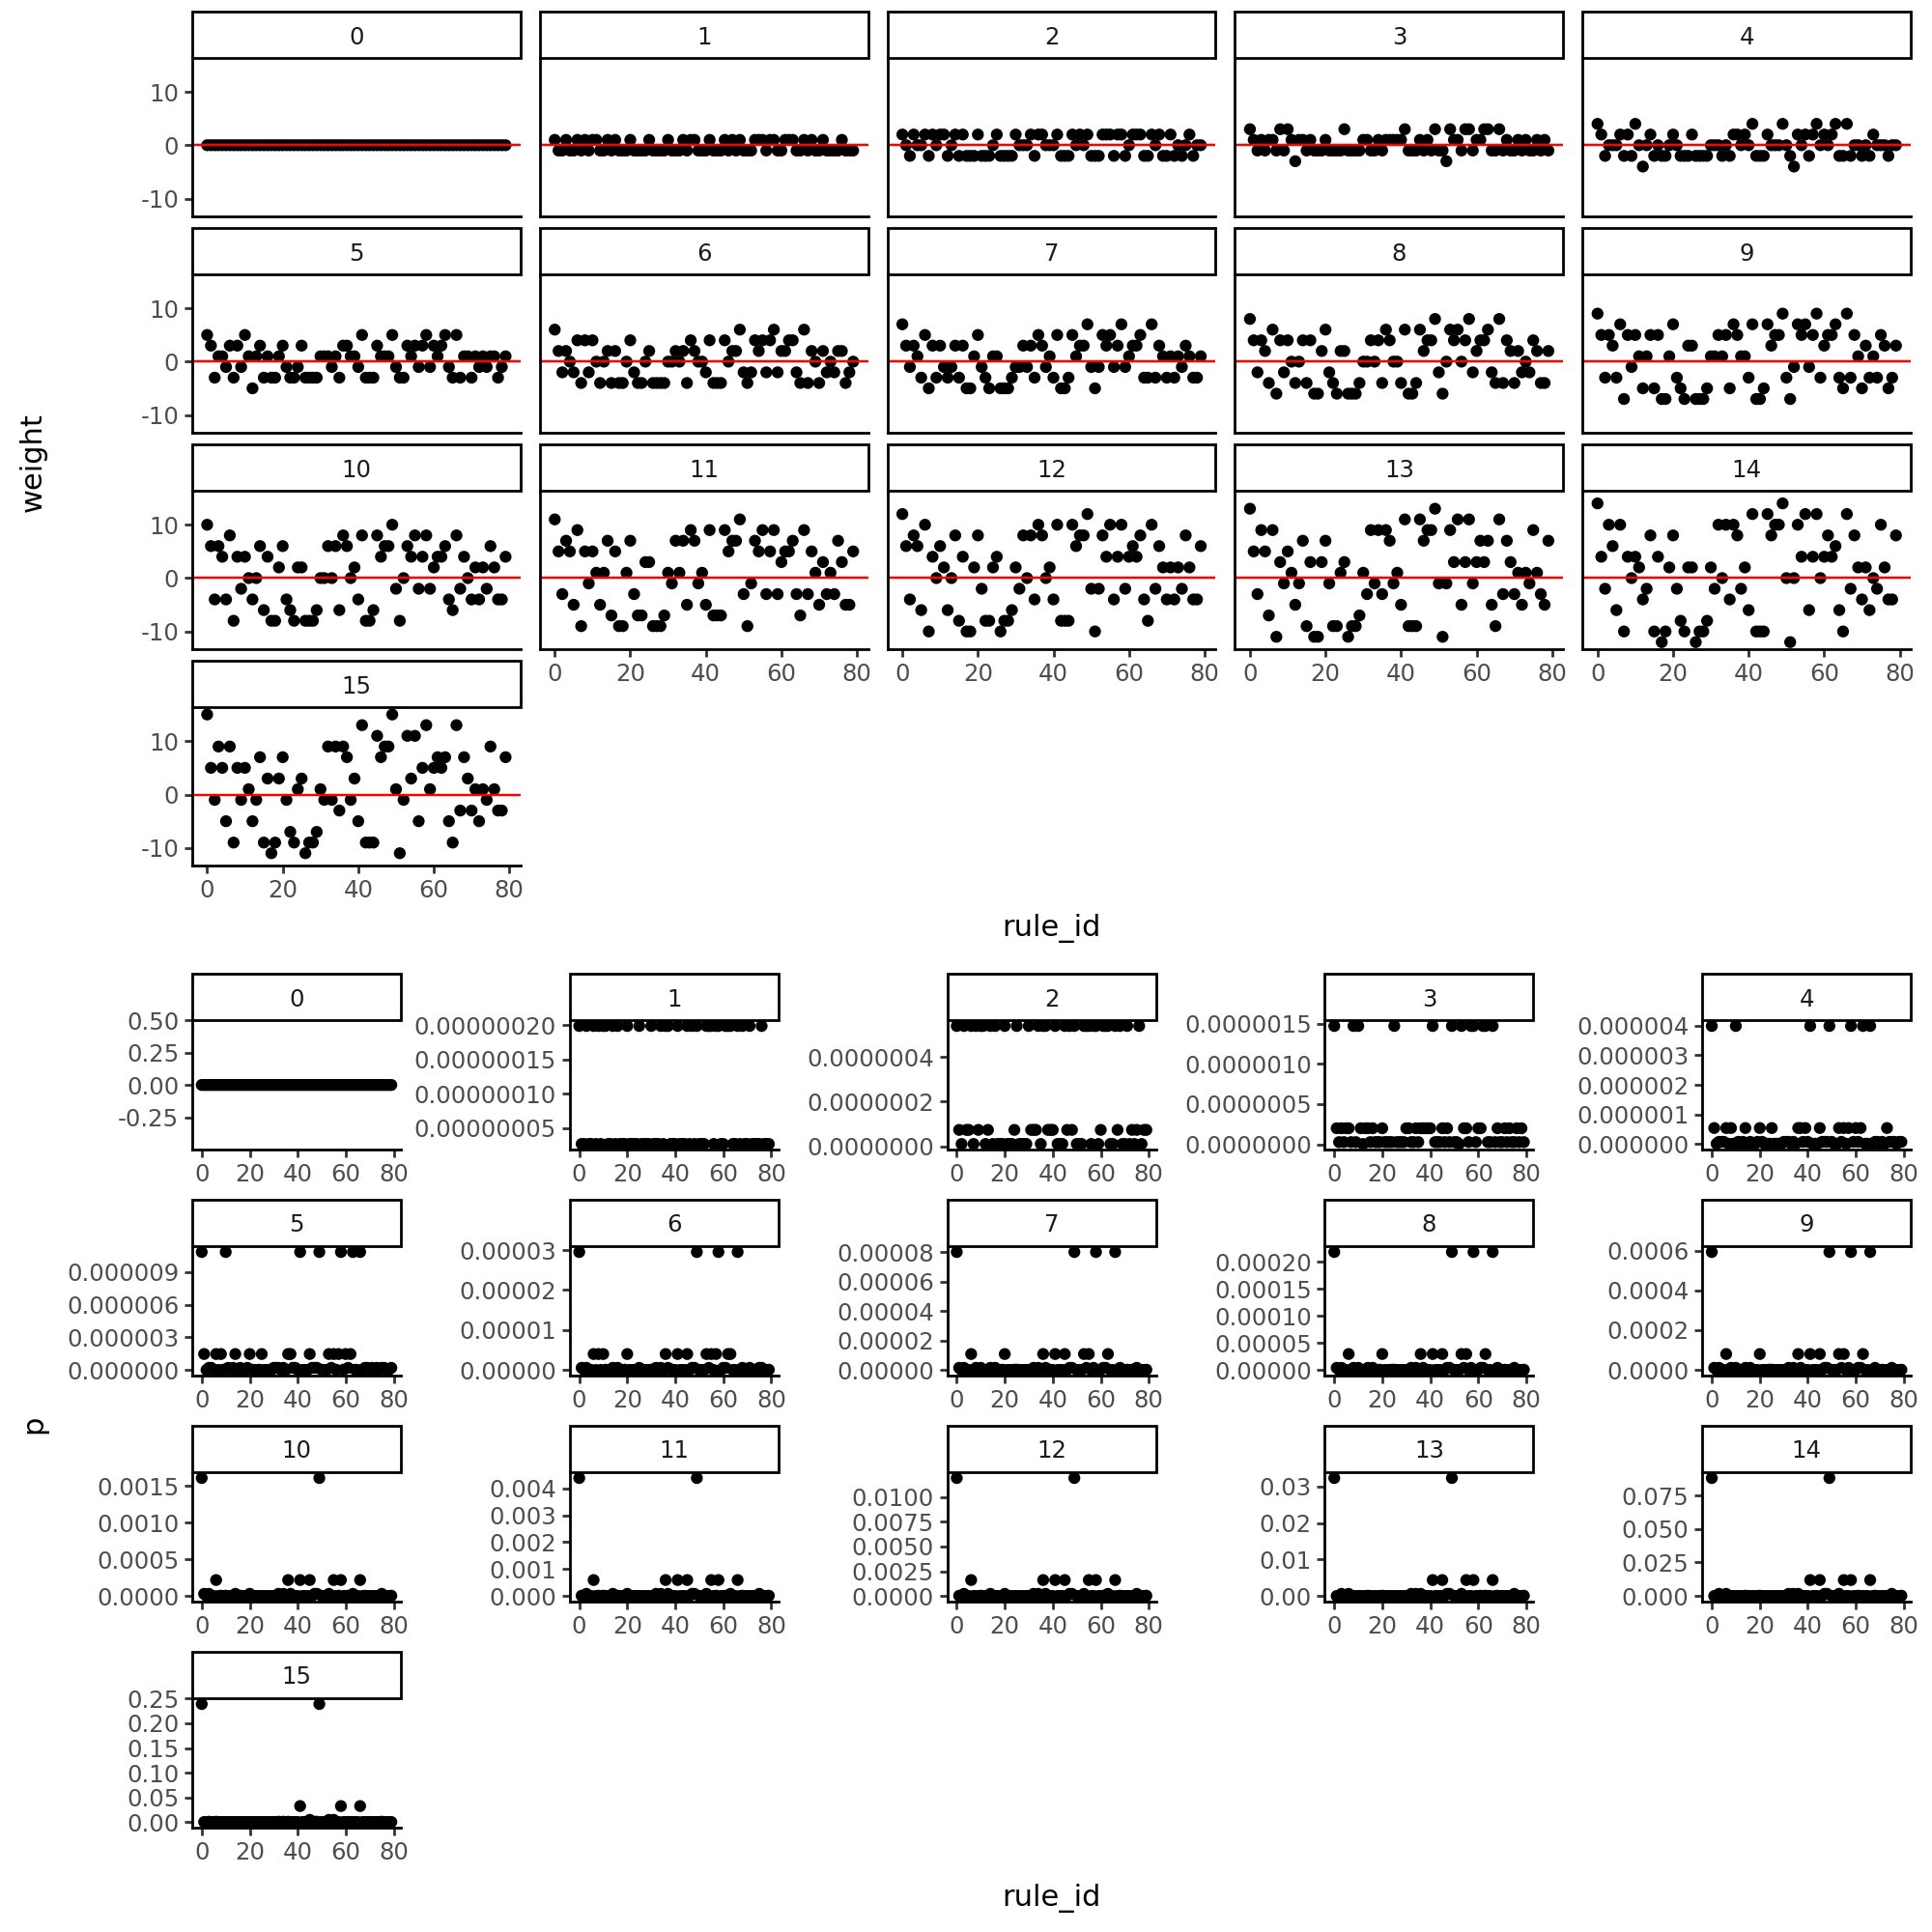

In [572]:
#filter for only 3dim rules
rule_ds = Dataset.from_parquet("rules.parquet")
ag_rules = rule_ds.filter(dim_3_filter)
true_rule = 'Thick_Legs and ( Arms_Down or Blue )'
n_t = 15
r = Rule(true_rule)
r.formalize_rule()

#init --> set weights to 1
ag_rules =ag_rules.map(weights)

for i in range(n_t):
    #get random stimuli
    stim = stimuli_maker()
    #no guesses here, this model assumes flawless information integration
    #if you say dangerous and it's correct you know that every rule that deems it dangerous gets + 
    #if you say its dangerous but it is not you know that every rule that deems it dangerous gets - 
    #check whether it is in accordance with true rule
    true_result = r.check_stimuli(stim)
    #all rules that aggree get + all rules that disagree get -
    ag_rules = ag_rules.map(real_rule_pass_based_weights, fn_kwargs={"passed":true_result,
     "stim":stim})
    

#with weights
df = ag_rules.to_pandas()
w_cols = pd.DataFrame(df["w"].to_list(), columns=[i for i in range(n_t+1)])
w_cols["rule_id"] = [i for i in range(80)]
#
df_2 = pd.DataFrame()
df_2["rule"] = df[["rule"]]
df_2["rule_id"] = [i for i in range(80)]
df_2 = df_2.merge(w_cols, on="rule_id").melt(["rule","rule_id"],value_name="weight",var_name="turn")

#with probs
ps = pd.DataFrame(np.transpose(softmax(np.transpose(ag_rules["w"]))))
ps["rule_id"] = [i for i in range(80)]
#
df_3 = pd.DataFrame()
df_3["rule"] = df[["rule"]]
df_3["rule_id"] = [i for i in range(80)]
df_3 = df_3.merge(ps, on="rule_id").melt(["rule","rule_id"],value_name="p",var_name="turn")


(
    ggplot(df_2,aes("rule_id","weight"))
    + geom_point()
    + facet_wrap("turn",ncol=5)
    + geom_abline(intercept = 0, slope = 0, color = "red")
    + theme_classic()
    + theme(figure_size=(6,10))

) / (


    ggplot(df_3,aes("rule_id","p"))
    + geom_point()
    + facet_wrap("turn",ncol=5,scales="free")
    + theme_classic()
    + theme(figure_size=(10,10))

)

In [472]:
#probabilities
#probability for each rule is a beta distribution
#were right / all times

#add prior probabilites to all
def set_beta_priors(ds,bp=[1,1]):
    ds.update({"beta":[bp]})
    ds.update({"mp":[bp[0]/(bp[0]+bp[1])]})
    return ds

def real_rule_pass_beta_prob(ds,passed:bool,stim:list[int]):
    """If rule is in accordance with real one, beta(x+1,y), else beta(x,y+1)"""
    passes = ds["passes"]
    #last_beta_vals = ds["beta"][-1]
    alpha = ds["beta"][-1][0]
    beta= ds["beta"][-1][1]

    if (passed and (stim in passes)) or (not passed and (stim not in passes)):
        ds["beta"].append([alpha+1,beta])
        ds["mp"].append((alpha+1)/((alpha+1)+beta))
    else:
        ds["beta"].append([alpha,beta+1])
        ds["mp"].append((alpha)/(alpha+(beta+1)))

    return ds

    

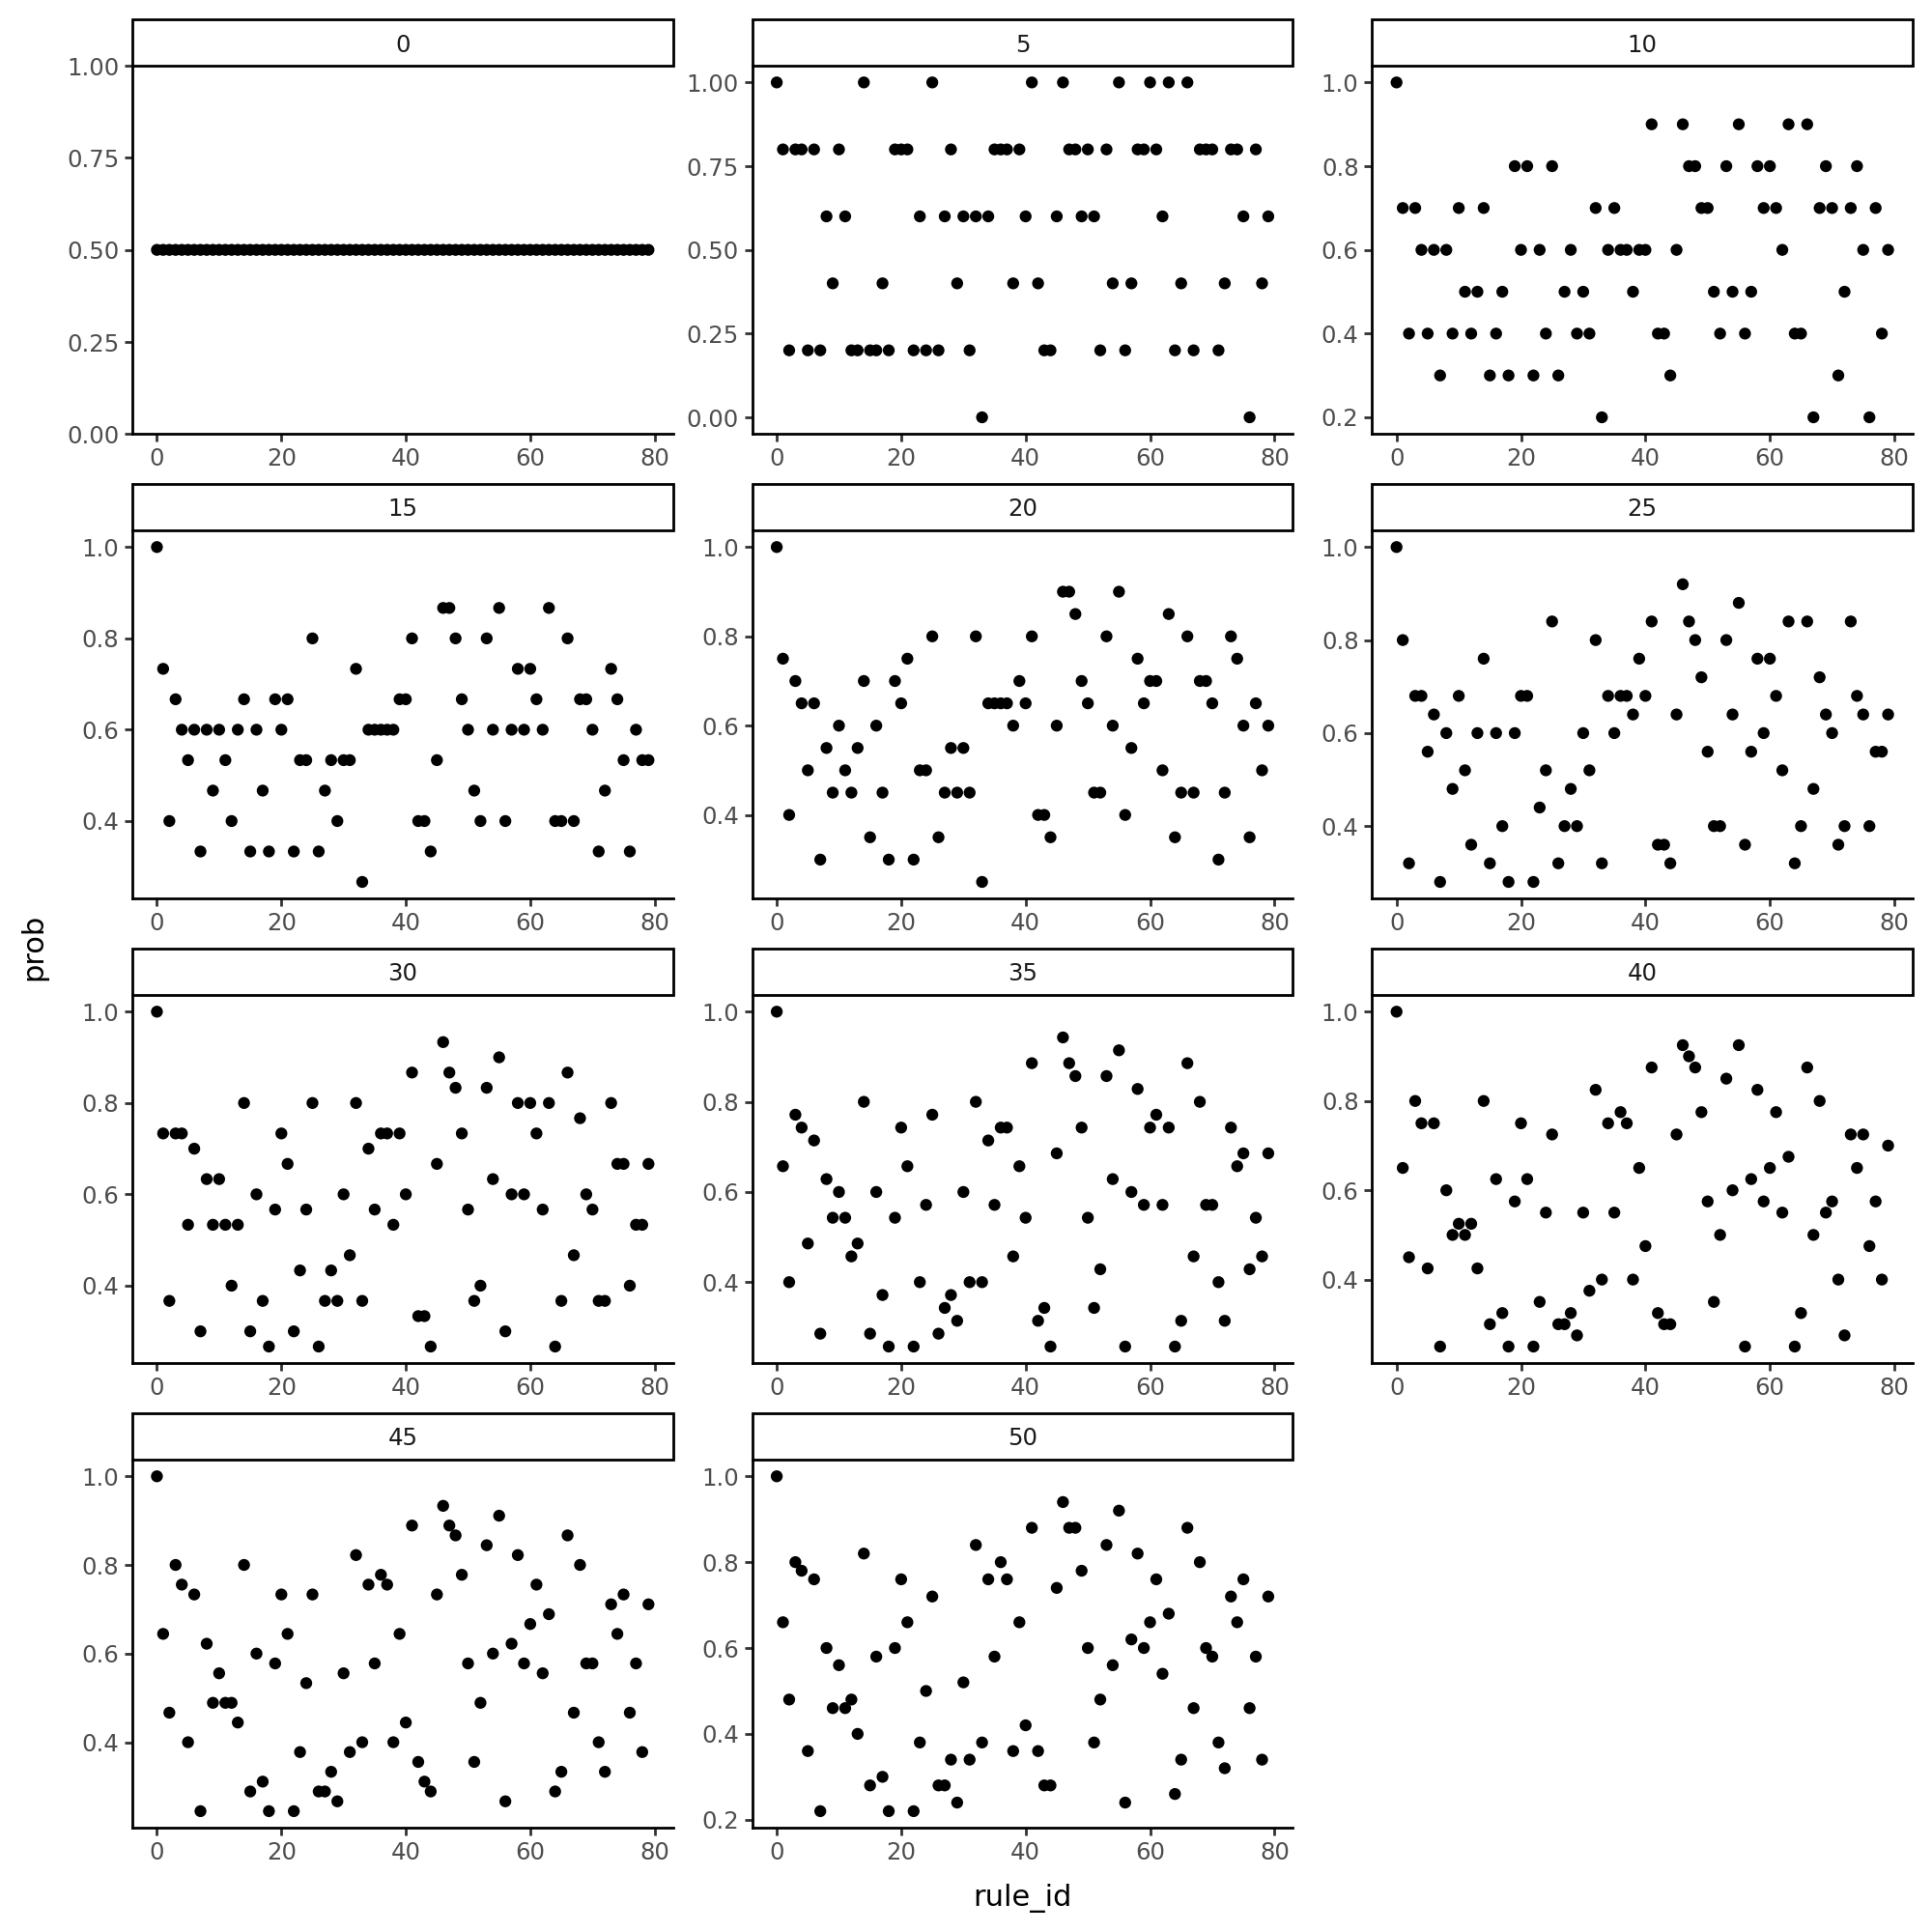

In [574]:
#filter for only 3dim rules
rule_ds = Dataset.from_parquet("rules.parquet")
ag_rules = rule_ds.filter(dim_3_filter)
true_rule = 'Thick_Legs and ( Arms_Down or Blue )'
n_t = 50
r = Rule(true_rule)
r.formalize_rule()

#init --> set weights to 1
ag_rules =ag_rules.map(set_beta_priors)
for i in range(n_t):
    #get random stimuli
    stim = stimuli_maker()
    true_result = r.check_stimuli(stim)
    #all rules that aggree get + all rules that disagree get -
    ag_rules = ag_rules.map(real_rule_pass_beta_prob, fn_kwargs={"passed":true_result,
     "stim":stim})

##wrangle the data
df = ag_rules.to_pandas()
p_cols = pd.DataFrame(df["mp"].to_list(), columns=[i for i in range(n_t+1)])
p_cols["rule_id"] = [i for i in range(80)]
beta_cols = pd.DataFrame(df["beta"].to_list(), columns=[i for i in range(n_t+1)])
beta_cols["rule_id"] = [i for i in range(80)]

df_2 = pd.DataFrame()
df_2["rule"] = df[["rule"]]
df_2["rule_id"] = [i for i in range(80)]
df_probs = df_2.merge(p_cols, on="rule_id").melt(["rule","rule_id"],value_name="prob",var_name="turn")
df_betas = df_2.merge(beta_cols, on="rule_id").melt(["rule","rule_id"],value_name="beta",var_name="turn")


#select the first 5 rules every 5th turn for visualizing the whole beta dist change
df_betas = df_betas[(df_betas["rule_id"] < 5) & (df_betas["turn"]%5==0)].reset_index()
#sample 100 vals from the betas
abcols = pd.DataFrame(df_betas["beta"].to_list(), columns=["a","b"])
df_betas["a"]= abcols["a"]
df_betas["b"]= abcols["b"]
draws = [pm.draw(pm.Beta.dist(a,b),100) for a,b in zip(df_betas["a"],df_betas["b"])]
df_betas["draws"] = draws
draw_cols = pd.DataFrame(df_betas["draws"].to_list(), columns=[i for i in range(100)])

df_betas= df_betas[["rule","rule_id","turn","beta","a","b"]].join(draw_cols).melt(["rule","rule_id","turn","beta","a","b"],var_name="draw")
df_betas["rule_id"] = df_betas["rule_id"].astype(str)

#select every 5th turn for displaying
(
    ggplot(df_probs[df_probs["turn"]%5==0],aes("rule_id","prob"))
    + geom_point()
    + facet_wrap("turn",ncol=3,scales="free",shrink=False)
    + theme_classic()
    + theme(figure_size=(10,10))

)

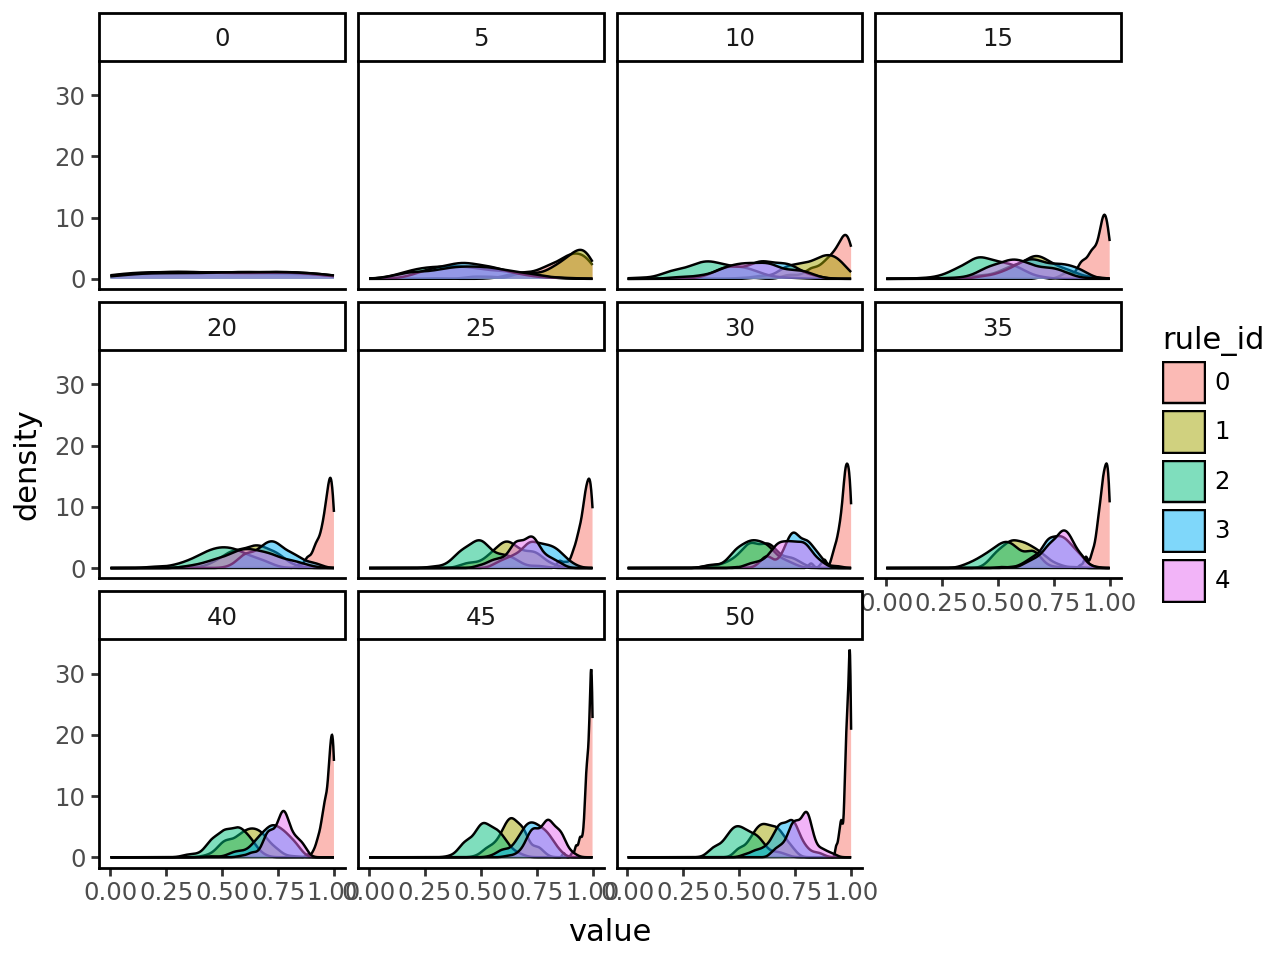

In [469]:
(
    ggplot(df_betas,aes("value",group="rule_id",fill="rule_id"))
           +geom_density(alpha= 0.5)
           +facet_wrap("turn")
           +theme_classic()
    )

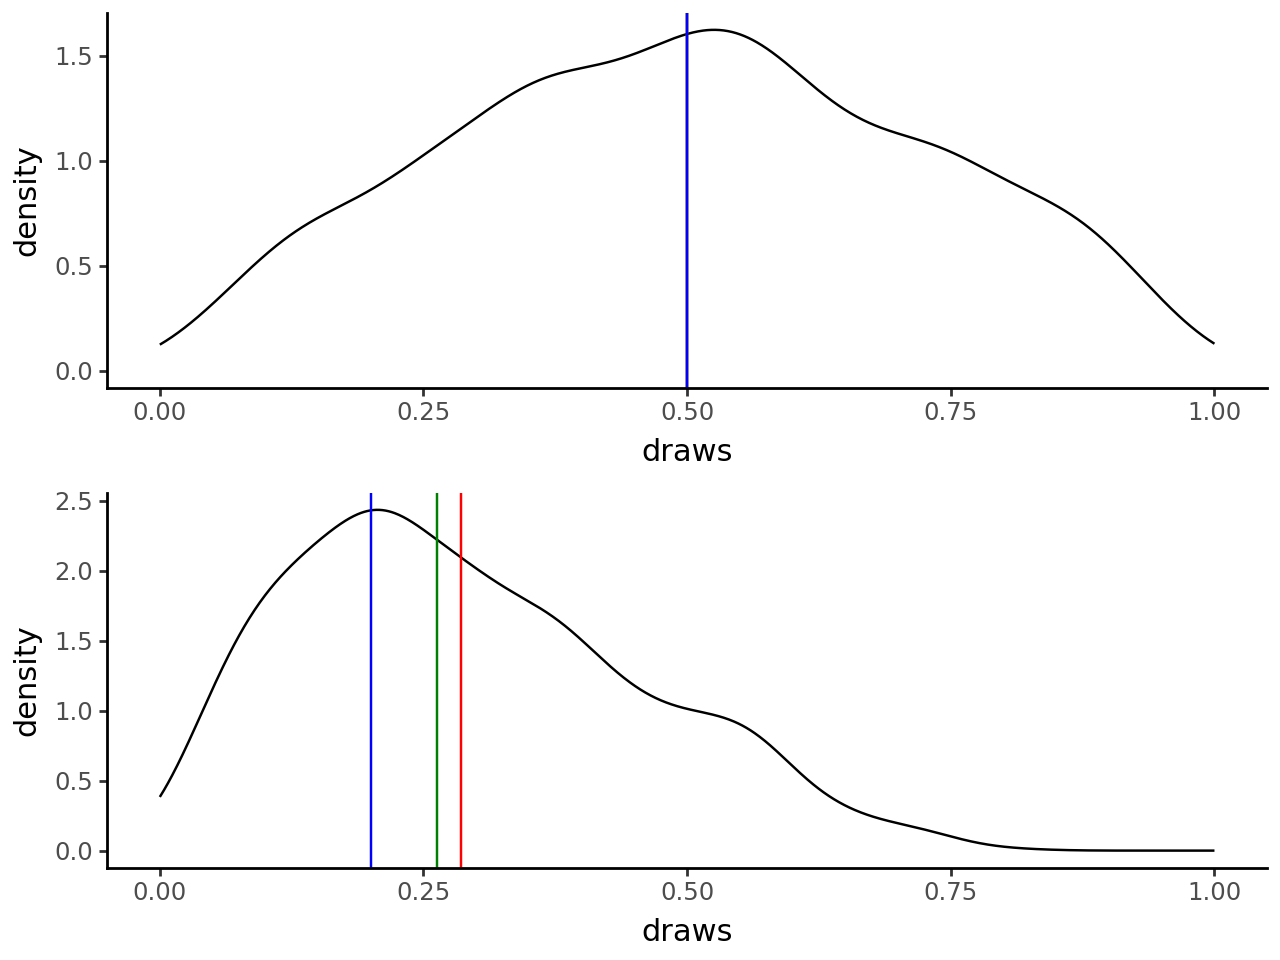

In [632]:
alpha = [2,2]
beta = [2,5]

d1 = list(pm.draw(pm.Beta.dist(alpha[0],beta[0]),1000))
d2 = list(pm.draw(pm.Beta.dist(alpha[1],beta[1]),1000))

df= pd.DataFrame({"draws":d1 + d2,
                  "v":["2,2" for i in range(1000)] + ["2,5" for i in range(1000)]})

(
    ggplot(df[df["v"] == "2,2"], aes("draws"))
    + geom_density()
    + geom_vline(xintercept=alpha[0]/(alpha[0]+beta[0]), color = "red")
    + geom_vline(xintercept=(alpha[0]-1/3)/(alpha[0]+beta[0]-2/3), color = "green")
    + geom_vline(xintercept = (alpha[0]-1)/(alpha[0]+beta[0]-2),
                 color="blue")
    + scale_x_continuous(limits=[0,1])
    + theme_classic()
) / (
    ggplot(df[df["v"] == "2,5"], aes("draws"))
    + geom_density()
    + geom_vline(xintercept=alpha[1]/(alpha[1]+beta[1]), color = "red")
    + geom_vline(xintercept=(alpha[1]-1/3)/(alpha[1]+beta[1]-2/3), color = "green")
    + geom_vline(xintercept = (alpha[1]-1)/(alpha[1]+beta[1]-2),
                 color="blue")
    + scale_x_continuous(limits=[0,1])
    + theme_classic()
)

In [ ]:
#small additions
#use median instead of mean
#change prior to 2,2

In [ ]:
def real_rule_pass_beta_prob(ds,passed:bool,stim:list[int]):
    """If rule is in accordance with real one, beta(x+1,y), else beta(x,y+1), also calc mode"""
    passes = ds["passes"]
    #last_beta_vals = ds["beta"][-1]
    alpha = ds["beta"][-1][0]
    beta= ds["beta"][-1][1]

    if (passed and (stim in passes)) or (not passed and (stim not in passes)):
        n_alpha = alpha +1
        n_beta = beta
    else:
        n_alpha = alpha
        n_beta = beta + 1
    ds["beta"].append([n_alpha,n_beta])
    ds["mp"].append((n_alpha-1)/(n_alpha+n_beta-2))

    return ds

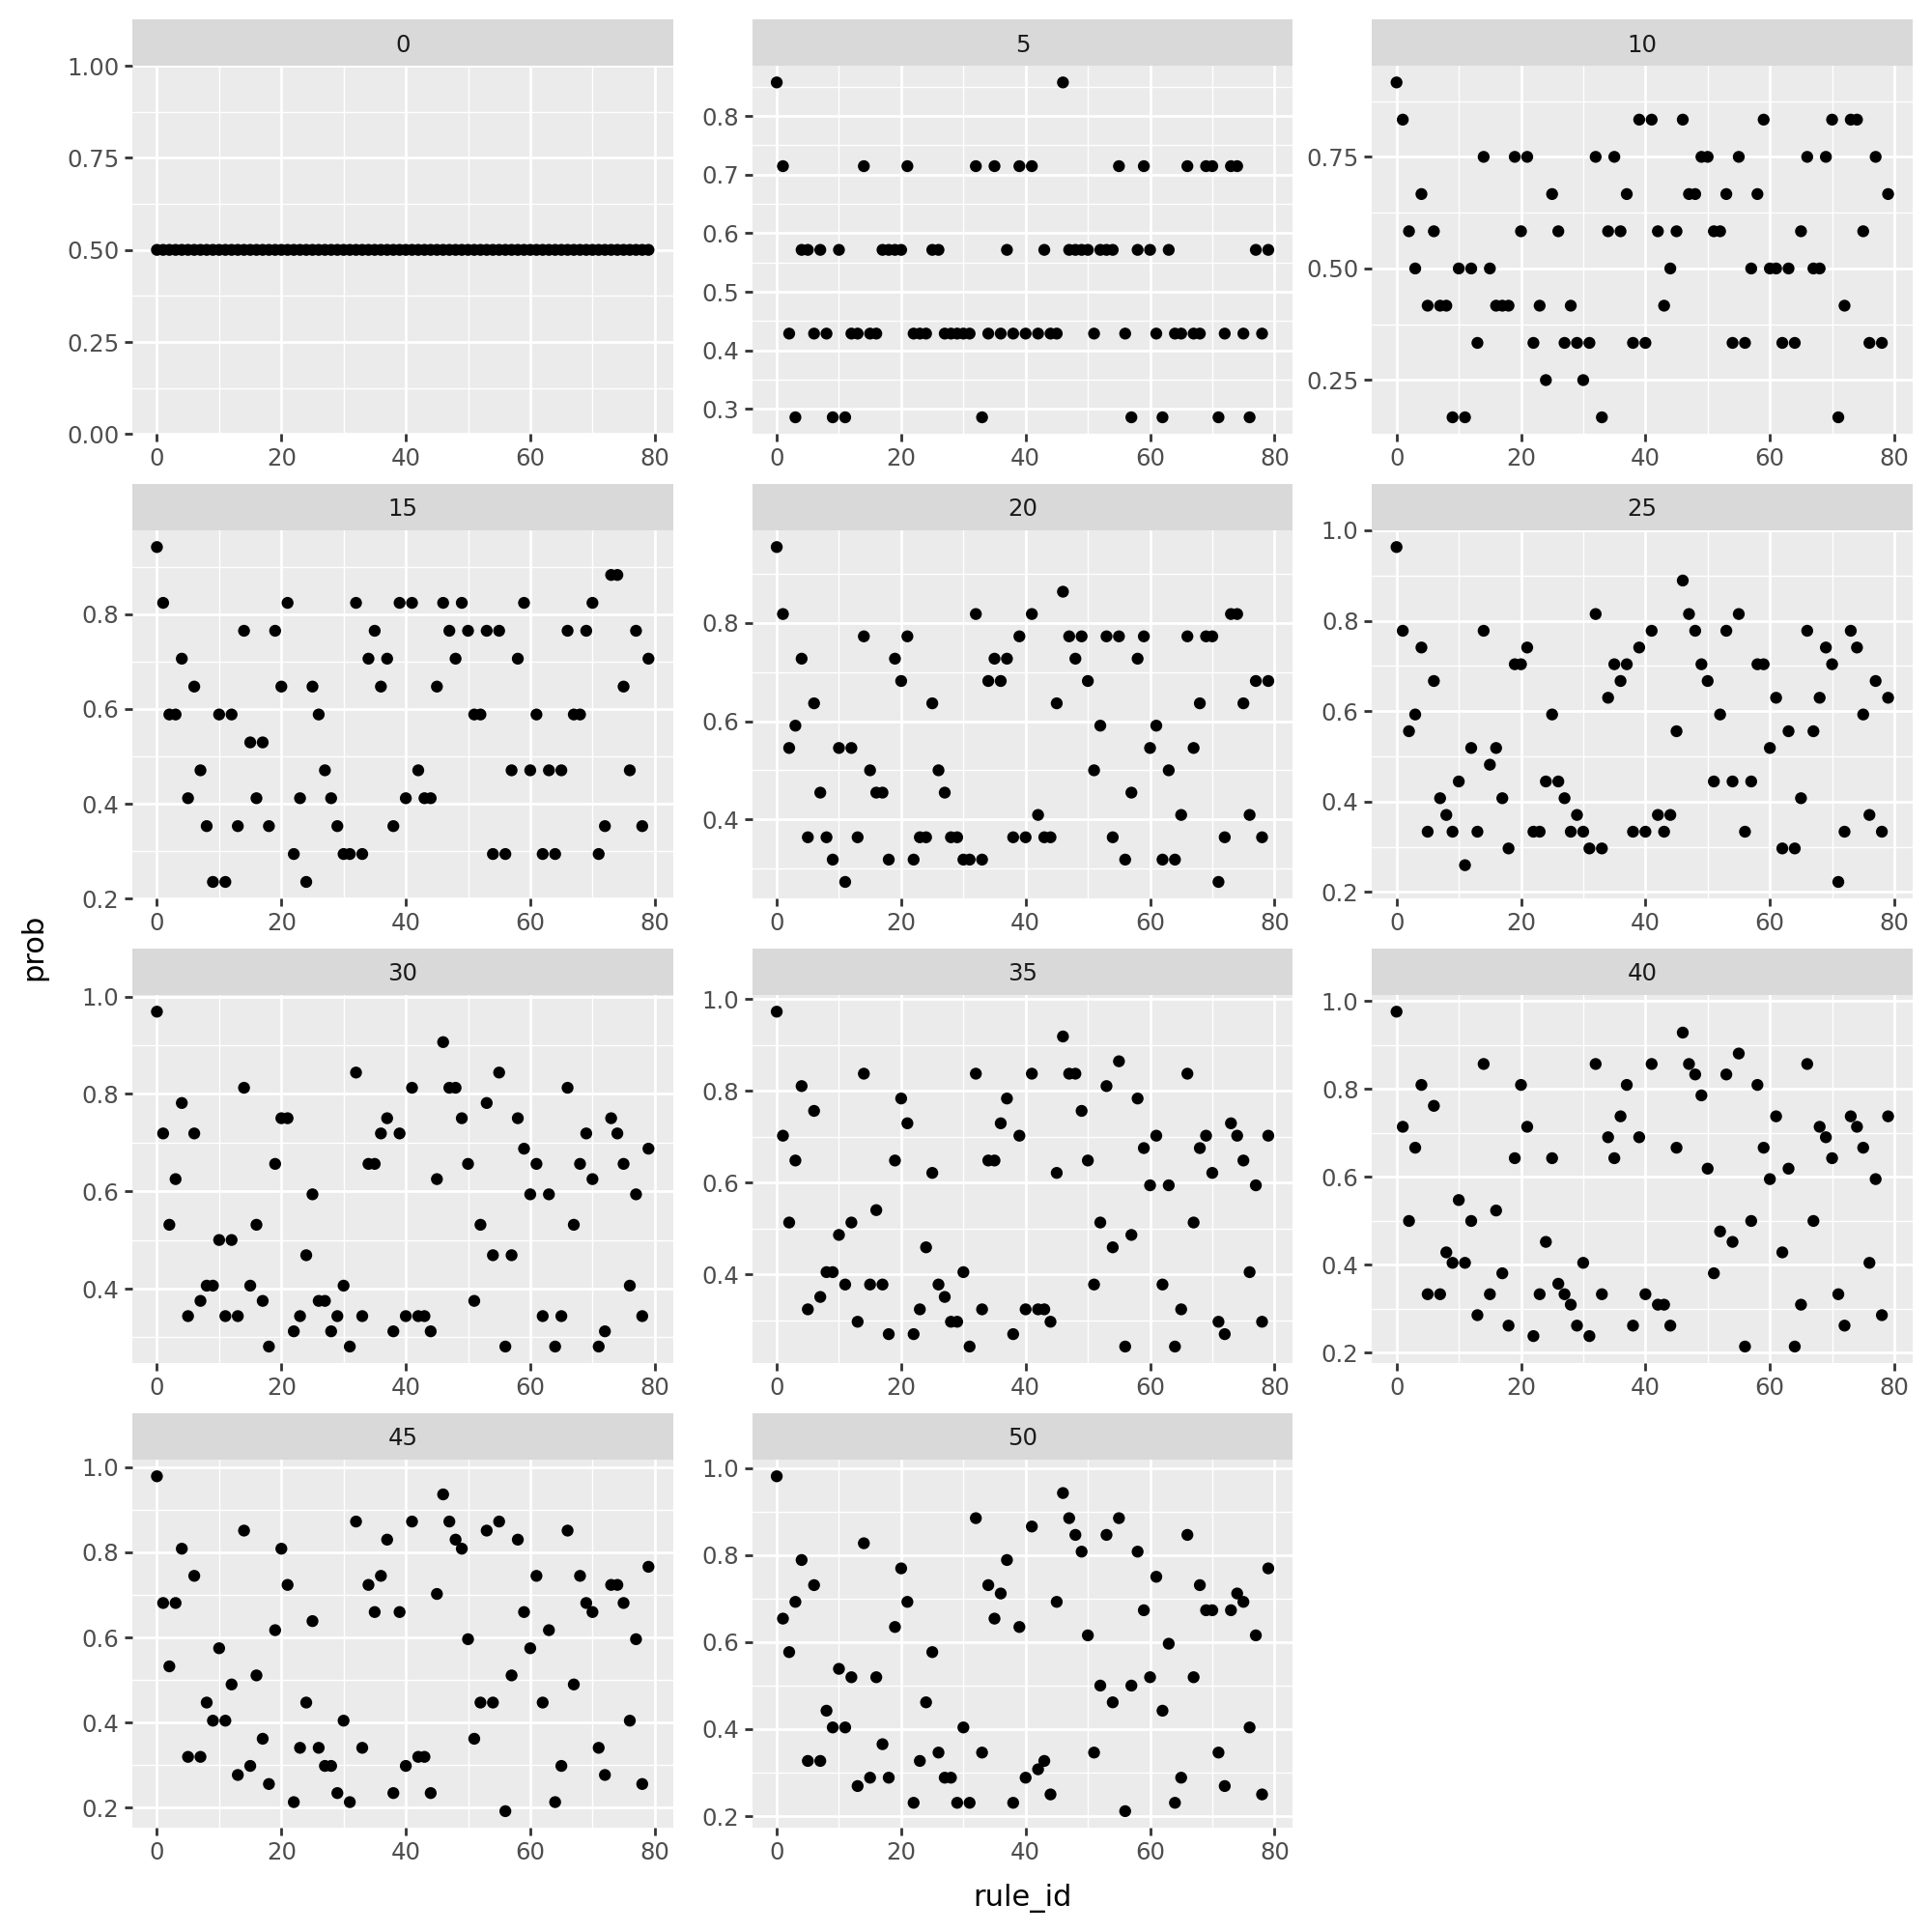

In [491]:
#filter for only 3dim rules
rule_ds = Dataset.from_parquet("rules.parquet")
ag_rules = rule_ds.filter(dim_3_filter)
true_rule = 'Thick_Legs and ( Arms_Down or Blue )'
n_t = 50
r = Rule(true_rule)
r.formalize_rule()

#init --> set weights to 1
ag_rules =ag_rules.map(set_beta_priors,fn_kwargs={"bp":[2,2]})
for i in range(n_t):
    #get random stimuli
    stim = stimuli_maker()
    true_result = r.check_stimuli(stim)
    #all rules that aggree get + all rules that disagree get -
    ag_rules = ag_rules.map(real_rule_pass_beta_prob, fn_kwargs={"passed":true_result,
     "stim":stim})

##wrangle the data
df = ag_rules.to_pandas()
p_cols = pd.DataFrame(df["mp"].to_list(), columns=[i for i in range(n_t+1)])
p_cols["rule_id"] = [i for i in range(80)]
beta_cols = pd.DataFrame(df["beta"].to_list(), columns=[i for i in range(n_t+1)])
beta_cols["rule_id"] = [i for i in range(80)]

df_2 = pd.DataFrame()
df_2["rule"] = df[["rule"]]
df_2["rule_id"] = [i for i in range(80)]
df_probs = df_2.merge(p_cols, on="rule_id").melt(["rule","rule_id"],value_name="prob",var_name="turn")
df_betas = df_2.merge(beta_cols, on="rule_id").melt(["rule","rule_id"],value_name="beta",var_name="turn")


#select the first 5 rules every 5th turn for visualizing the whole beta dist change
df_betas = df_betas[(df_betas["rule_id"] < 5) & (df_betas["turn"]%5==0)].reset_index()
#sample 100 vals from the betas
abcols = pd.DataFrame(df_betas["beta"].to_list(), columns=["a","b"])
df_betas["a"]= abcols["a"]
df_betas["b"]= abcols["b"]
draws = [pm.draw(pm.Beta.dist(a,b),100) for a,b in zip(df_betas["a"],df_betas["b"])]
df_betas["draws"] = draws
draw_cols = pd.DataFrame(df_betas["draws"].to_list(), columns=[i for i in range(100)])

df_betas= df_betas[["rule","rule_id","turn","beta","a","b"]].join(draw_cols).melt(["rule","rule_id","turn","beta","a","b"],var_name="draw")
df_betas["rule_id"] = df_betas["rule_id"].astype(str)

#select every 5th turn for displaying
(
    ggplot(df_probs[df_probs["turn"]%5==0],aes("rule_id","prob"))
    + geom_point()
    + facet_wrap("turn",ncol=3,scales="free",shrink=False)
    + theme(figure_size=(10,10))

)

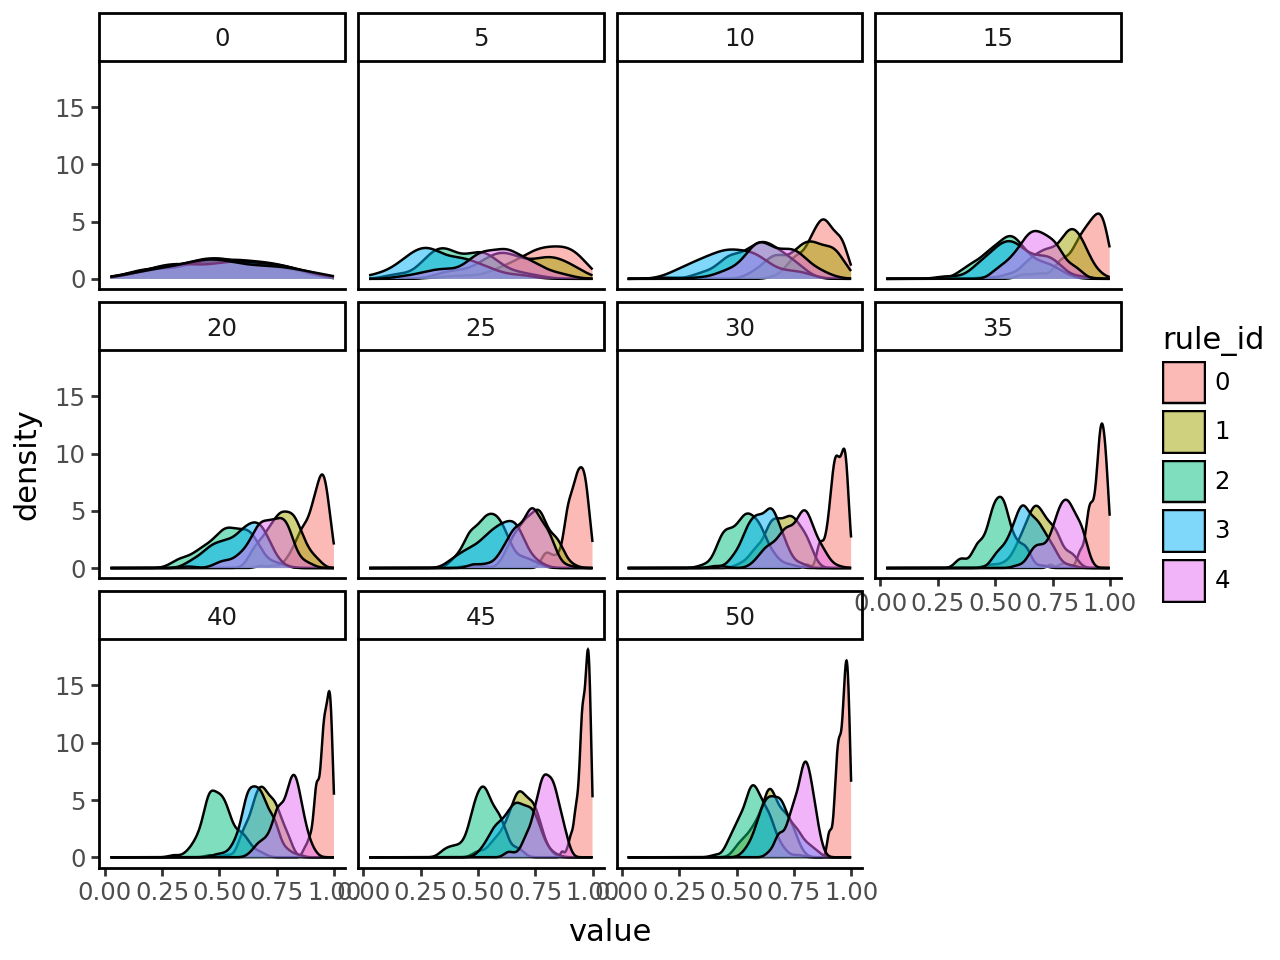

In [529]:
from scipy.special import softmax, logit

In [ ]:
#ok now add the memory because it is unlikely all 80 rules are kept in memory/attention at the same time


In [ ]:
#2.1 Memory + unconnected rules, random sampling at each turn

In [596]:
def rrp_beta_prob_mem(ds,passed:bool,stim:list[int], id_list:list[int]):
    """If rule is in accordance with real one, beta(x+1,y), else beta(x,y+1), also calc mode.
    With memory - only rules with ids in the list are updated 
    """
    passes = ds["passes"]
    #last_beta_vals = ds["beta"][-1]
    alpha = ds["beta"][-1][0]
    beta= ds["beta"][-1][1]

    if ds["rule_id"] in id_list:

        if (passed and (stim in passes)) or (not passed and (stim not in passes)):
            n_alpha = alpha +1
            n_beta = beta
        else:
            n_alpha = alpha
            n_beta = beta + 1
            
    else:
        n_alpha=alpha
        n_beta=beta
        
    ds["beta"].append([n_alpha,n_beta])
    ds["mp"].append((n_alpha-1)/(n_alpha+n_beta-2))

    return ds

In [605]:
#filter for only 3dim rules
rule_ds = Dataset.from_parquet("rules.parquet")
ag_rules = rule_ds.filter(dim_3_filter)
#add ids
ag_rules = ag_rules.add_column("rule_id",[i for i in range(80)])
true_rule = 'Thick_Legs and ( Arms_Down or Blue )'
n_t = 50
r = Rule(true_rule)
r.formalize_rule()

#set vars
memory = 5

#init --> set weights to 1
ag_rules =ag_rules.map(set_beta_priors,fn_kwargs={"bp":[2,2]})
for i in range(n_t):
    #get random stimuli
    stim = stimuli_maker()
    true_result = r.check_stimuli(stim)
    #only check n memory rules
    max_id = len(ag_rules["rule_id"])-1
    ids_to_update = [random.randint(0,max_id) for i in range(memory)]

    #all rules that aggree get + all rules that disagree get -
    ag_rules = ag_rules.map(rrp_beta_prob_mem, fn_kwargs={"passed":true_result,
     "stim":stim,
     "id_list":ids_to_update})
    
p1, p2 = make_plots(ag_rules)

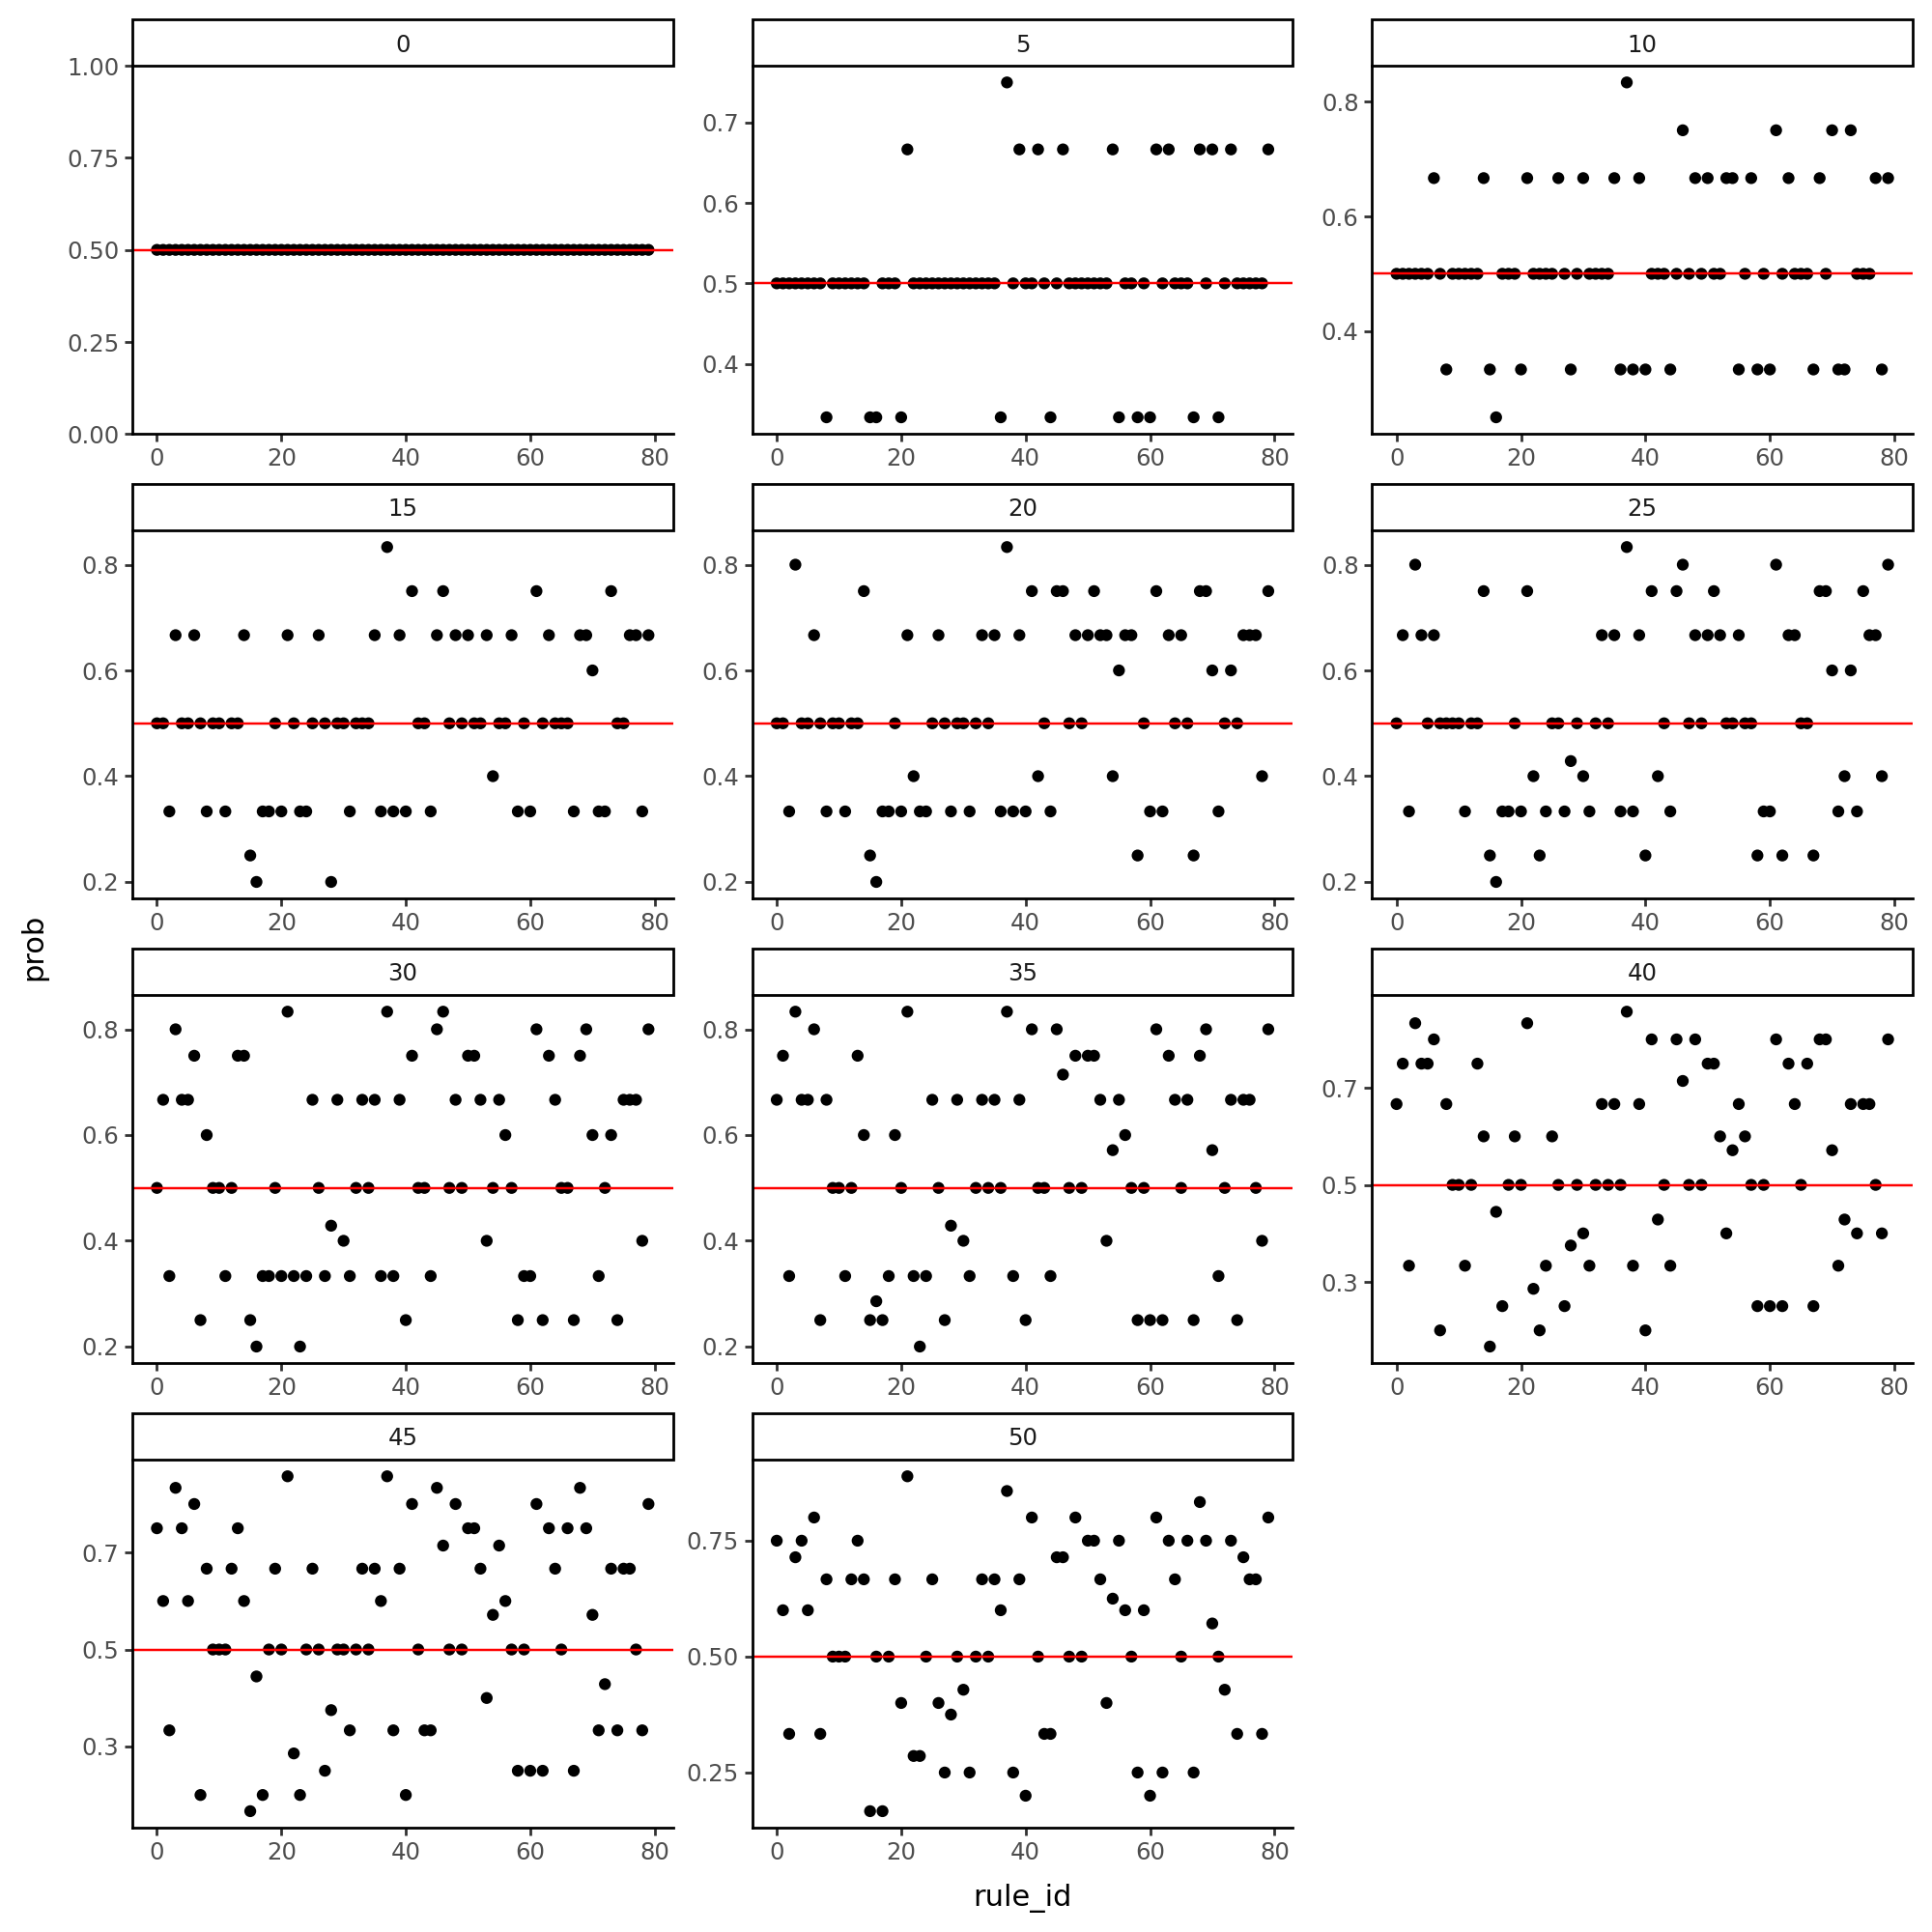

In [633]:
p1

In [ ]:
#2.2 subset changes periodically (after x turns)

In [648]:
#set sampling intervals
#filter for only 3dim rules
rule_ds = Dataset.from_parquet("rules.parquet")
ag_rules = rule_ds.filter(dim_3_filter)
#add ids
ag_rules = ag_rules.add_column("rule_id",[i for i in range(80)])
true_rule = 'Thick_Legs and ( Arms_Down or Blue )'
n_t = 50
r = Rule(true_rule)
r.formalize_rule()

#set vars
memory = 5
#resampling interval
rs_turns = 5

#init --> set weights to 1
ag_rules =ag_rules.map(set_beta_priors,fn_kwargs={"bp":[2,2]})
for i in range(n_t):
    #get random stimuli
    stim = stimuli_maker()
    true_result = r.check_stimuli(stim)
    #only check n memory rules, change every x turns
    max_id = len(ag_rules["rule_id"])-1
    if i%rs_turns==0:
        ids_to_update = [random.randint(0,max_id) for i in range(memory)]
    else: 
        pass

    #all rules that aggree get + all rules that disagree get -
    ag_rules = ag_rules.map(rrp_beta_prob_mem, fn_kwargs={"passed":true_result,
     "stim":stim,
     "id_list":ids_to_update})
    
p1, p2 = make_plots(ag_rules)

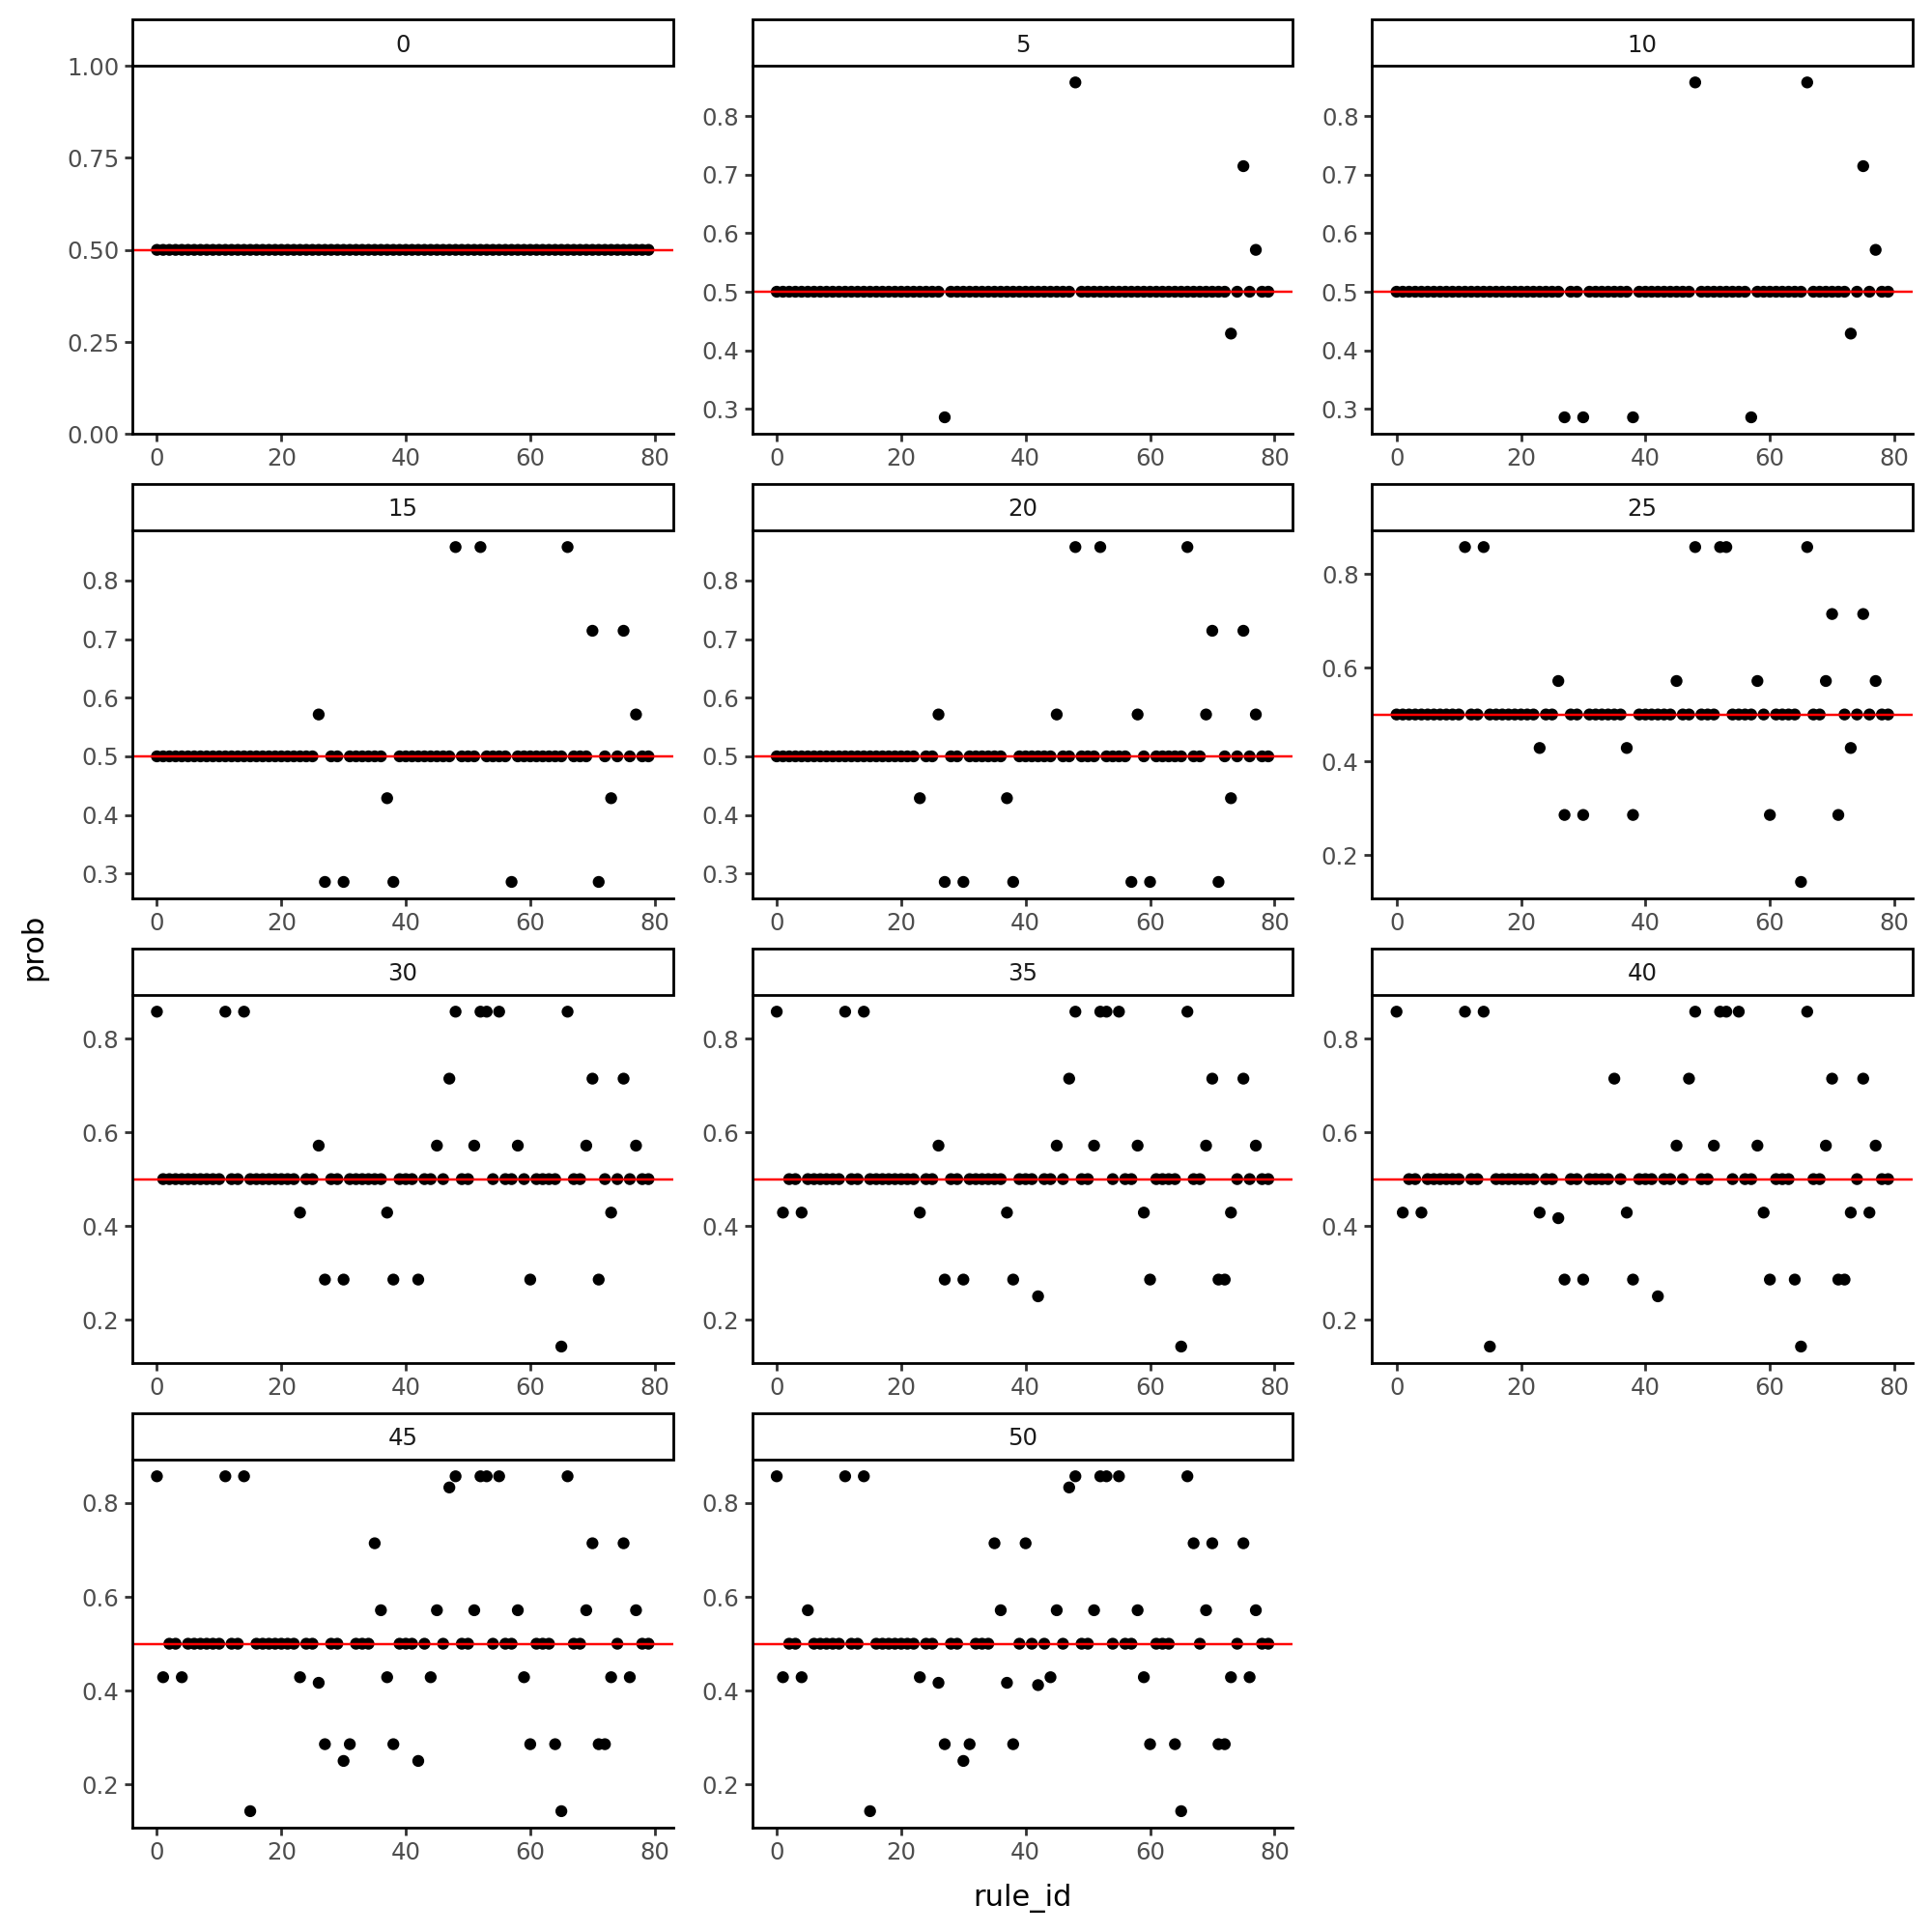

In [649]:
p1

In [ ]:
#2.3 subset changes dynamically (low ones drop based on threshold)

In [ ]:
#set sampling intervals
#filter for only 3dim rules
rule_ds = Dataset.from_parquet("rules.parquet")
ag_rules = rule_ds.filter(dim_3_filter)
#add ids
ag_rules = ag_rules.add_column("rule_id",[i for i in range(80)])
true_rule = 'Thick_Legs and ( Arms_Down or Blue )'
n_t = 50
r = Rule(true_rule)
r.formalize_rule()

#set vars
memory = 5
#resampling interval
rs_turns = 5

#init --> set weights to 1
ag_rules =ag_rules.map(set_beta_priors,fn_kwargs={"bp":[2,2]})
for i in range(n_t):
    #get random stimuli
    stim = stimuli_maker()
    true_result = r.check_stimuli(stim)
    #only check n memory rules, change every x turns
    max_id = len(ag_rules["rule_id"])-1
    if i%rs_turns==0:
        ids_to_update = [random.randint(0,max_id) for i in range(memory)]
    else: 
        pass

    #all rules that aggree get + all rules that disagree get -
    ag_rules = ag_rules.map(rrp_beta_prob_mem, fn_kwargs={"passed":true_result,
     "stim":stim,
     "id_list":ids_to_update})
    
p1, p2 = make_plots(ag_rules)

In [ ]:
#2 és fél 
# most
# van 5 szabály  elsö kör [0.6,0.6,0.4,0.4,0.4] ids [0,1,2,3,4]
# második kör [0.7,0.7,0.3,0.3,0.5] ids [0,1,2,3,4] [+,+,-,-,+]
# harmadik kör [0.8,0.6,0.2,0.4,0.6] ids ... [+,-,-,+,+]

#BPF type resampling?
# van 5 szabály  elsö kör !!!after evidence!!! [0.6,0.6,0.4,0.4,0.4] ids [0,1,2,3,4]
# resample ids based on 
# pm.draw(pm.Categorical.dist(logit_p=logit([0.5,0.5,0.5,0.5,0.5])),5)ids= array([4, 3, 0, 2, 4])
# so the update(meaning the alpha+1, beta+1) is only made on these ids, the rest stays as before the evidence

#so probs before anything [0.5,0.5,0.5,0.5,0.5]
#these would become [0.6,0.6,0.4,0.4,0.4]

# NOTE do we sample ids from before or after update
# before would mean attention, not all 5 receive equal attention
# after ???

#this is a mock example in the model not point estimates are added
#but beta(alpah,beta) are updated

#but instead only ids [4, 3, 0, 2, 4] are updated
# so [0.5 -> 0.6, 
#   0.5 -> 0.5, not updated
#   0.5 -> 0.4,
#   0.5 -> 0.4,
#   0.5 -> 0.4 -> 0.3, updated 2 times
#]



# második kör [0.6,0.5,0.4,0.4,0.3] ids [1,2,3,4,5]
# categorical sampling
# ids draw array([2, 4, 3, 0, 3])
# update [+,+,-,-,+] 
#so [0.6->0.7,
# 0.5->0.5,
# 0.4->0.3,
# 0.4->0.3->0.2,
# 0.3 -> 0.4]
#  at the end of turn [0.7,0.5,0.3,0.2,0.4]


# harmadik kör [0.7,0.5,0.3,0.2,0.4] [+,-,-,+,+]
# categorical sampling
# ids draw array([4, 4, 1, 0, 4])
#so [0.7->0.8,
# 0.5->0.4,
# 0.3->0.3,
# 0.2->0.2,
# 0.4 -> 0.5 -> 0.6 -> 0.7]
# at the end of turn [0.8,0.4,0.3,0.2,0.7]



In [832]:
def select_ids_on_p(id_list:list[int],betas:list[list[int]]):
    """ take n ids and their corresponding beta dist parameters
    draw a probability for each rule
    resample the ids pased on the probability, higher probs have higher chance of being sampled multiple times"""

    alpha_beta = np.array(betas).transpose()
    probs = pm.draw(pm.Beta.dist(alpha_beta[0],alpha_beta[1]))
    #logit cus they might sum upt more than 1
    resampled_ids = pm.draw(pm.Categorical.dist(logit_p=logit(probs)),len(id_list))
    resampled_ids = np.array(id_list)[resampled_ids]
    
    return resampled_ids

def rrp_beta_mem_BPF(ds,passed:bool,stim:list[int], id_list:list[int]):
    """If rule is in accordance with real one, beta(x+1,y), else beta(x,y+1), also calc mode.
    With memory - only rules with ids in the list are updated
    With BPF like sampling - rules are updated based on probability!
    some rules are updated multiple times, some not even once
    """
    passes = ds["passes"]
    #last_beta_vals = ds["beta"][-1]
    alpha = ds["beta"][-1][0]
    beta= ds["beta"][-1][1]

    #id occurences
    id_occ = id_list.count(ds["rule_id"])
    
    if (passed and (stim in passes)) or (not passed and (stim not in passes)):
            n_alpha = alpha + (1*id_occ)
            n_beta = beta
    else:
            n_alpha = alpha
            n_beta = beta + (1*id_occ)
            
        
    ds["beta"].append([n_alpha,n_beta])
    ds["mp"].append((n_alpha-1)/(n_alpha+n_beta-2))

    return ds

In [834]:
#set sampling intervals
#filter for only 3dim rules
rule_ds = Dataset.from_parquet("rules.parquet")
ag_rules = rule_ds.filter(dim_3_filter)
#add ids
ag_rules = ag_rules.add_column("rule_id",[i for i in range(80)])
true_rule = 'Thick_Legs and ( Arms_Down or Blue )'
n_t = 50
r = Rule(true_rule)
r.formalize_rule()

#set vars
memory = 5
#resampling interval
rs_turns = 5

#init --> set weights to 1
ag_rules =ag_rules.map(set_beta_priors,fn_kwargs={"bp":[2,2]})
for i in range(n_t):
    #get random stimuli
    stim = stimuli_maker()
    true_result = r.check_stimuli(stim)
    #only check n memory rules, change every x turns
    max_id = len(ag_rules["rule_id"])-1
    if i%rs_turns==0:
        ids_to_update = [random.randint(0,max_id) for i in range(memory)]
    else: 
        pass

    #resample the ids based on probs
    #all_betas for that id
    ab = np.array(ag_rules.filter(lambda ds: ds["rule_id"] in ids_to_update)["beta"])
    #keep only the last betas
    ab = ab[:,-1]
    res_ids = list(select_ids_on_p(ids_to_update,ab))

    #all rules that aggree get + all rules that disagree get -
    ag_rules = ag_rules.map(rrp_beta_mem_BPF, fn_kwargs={"passed":true_result,
     "stim":stim,
     "id_list":res_ids})
    
p1, p2 = make_plots(ag_rules)

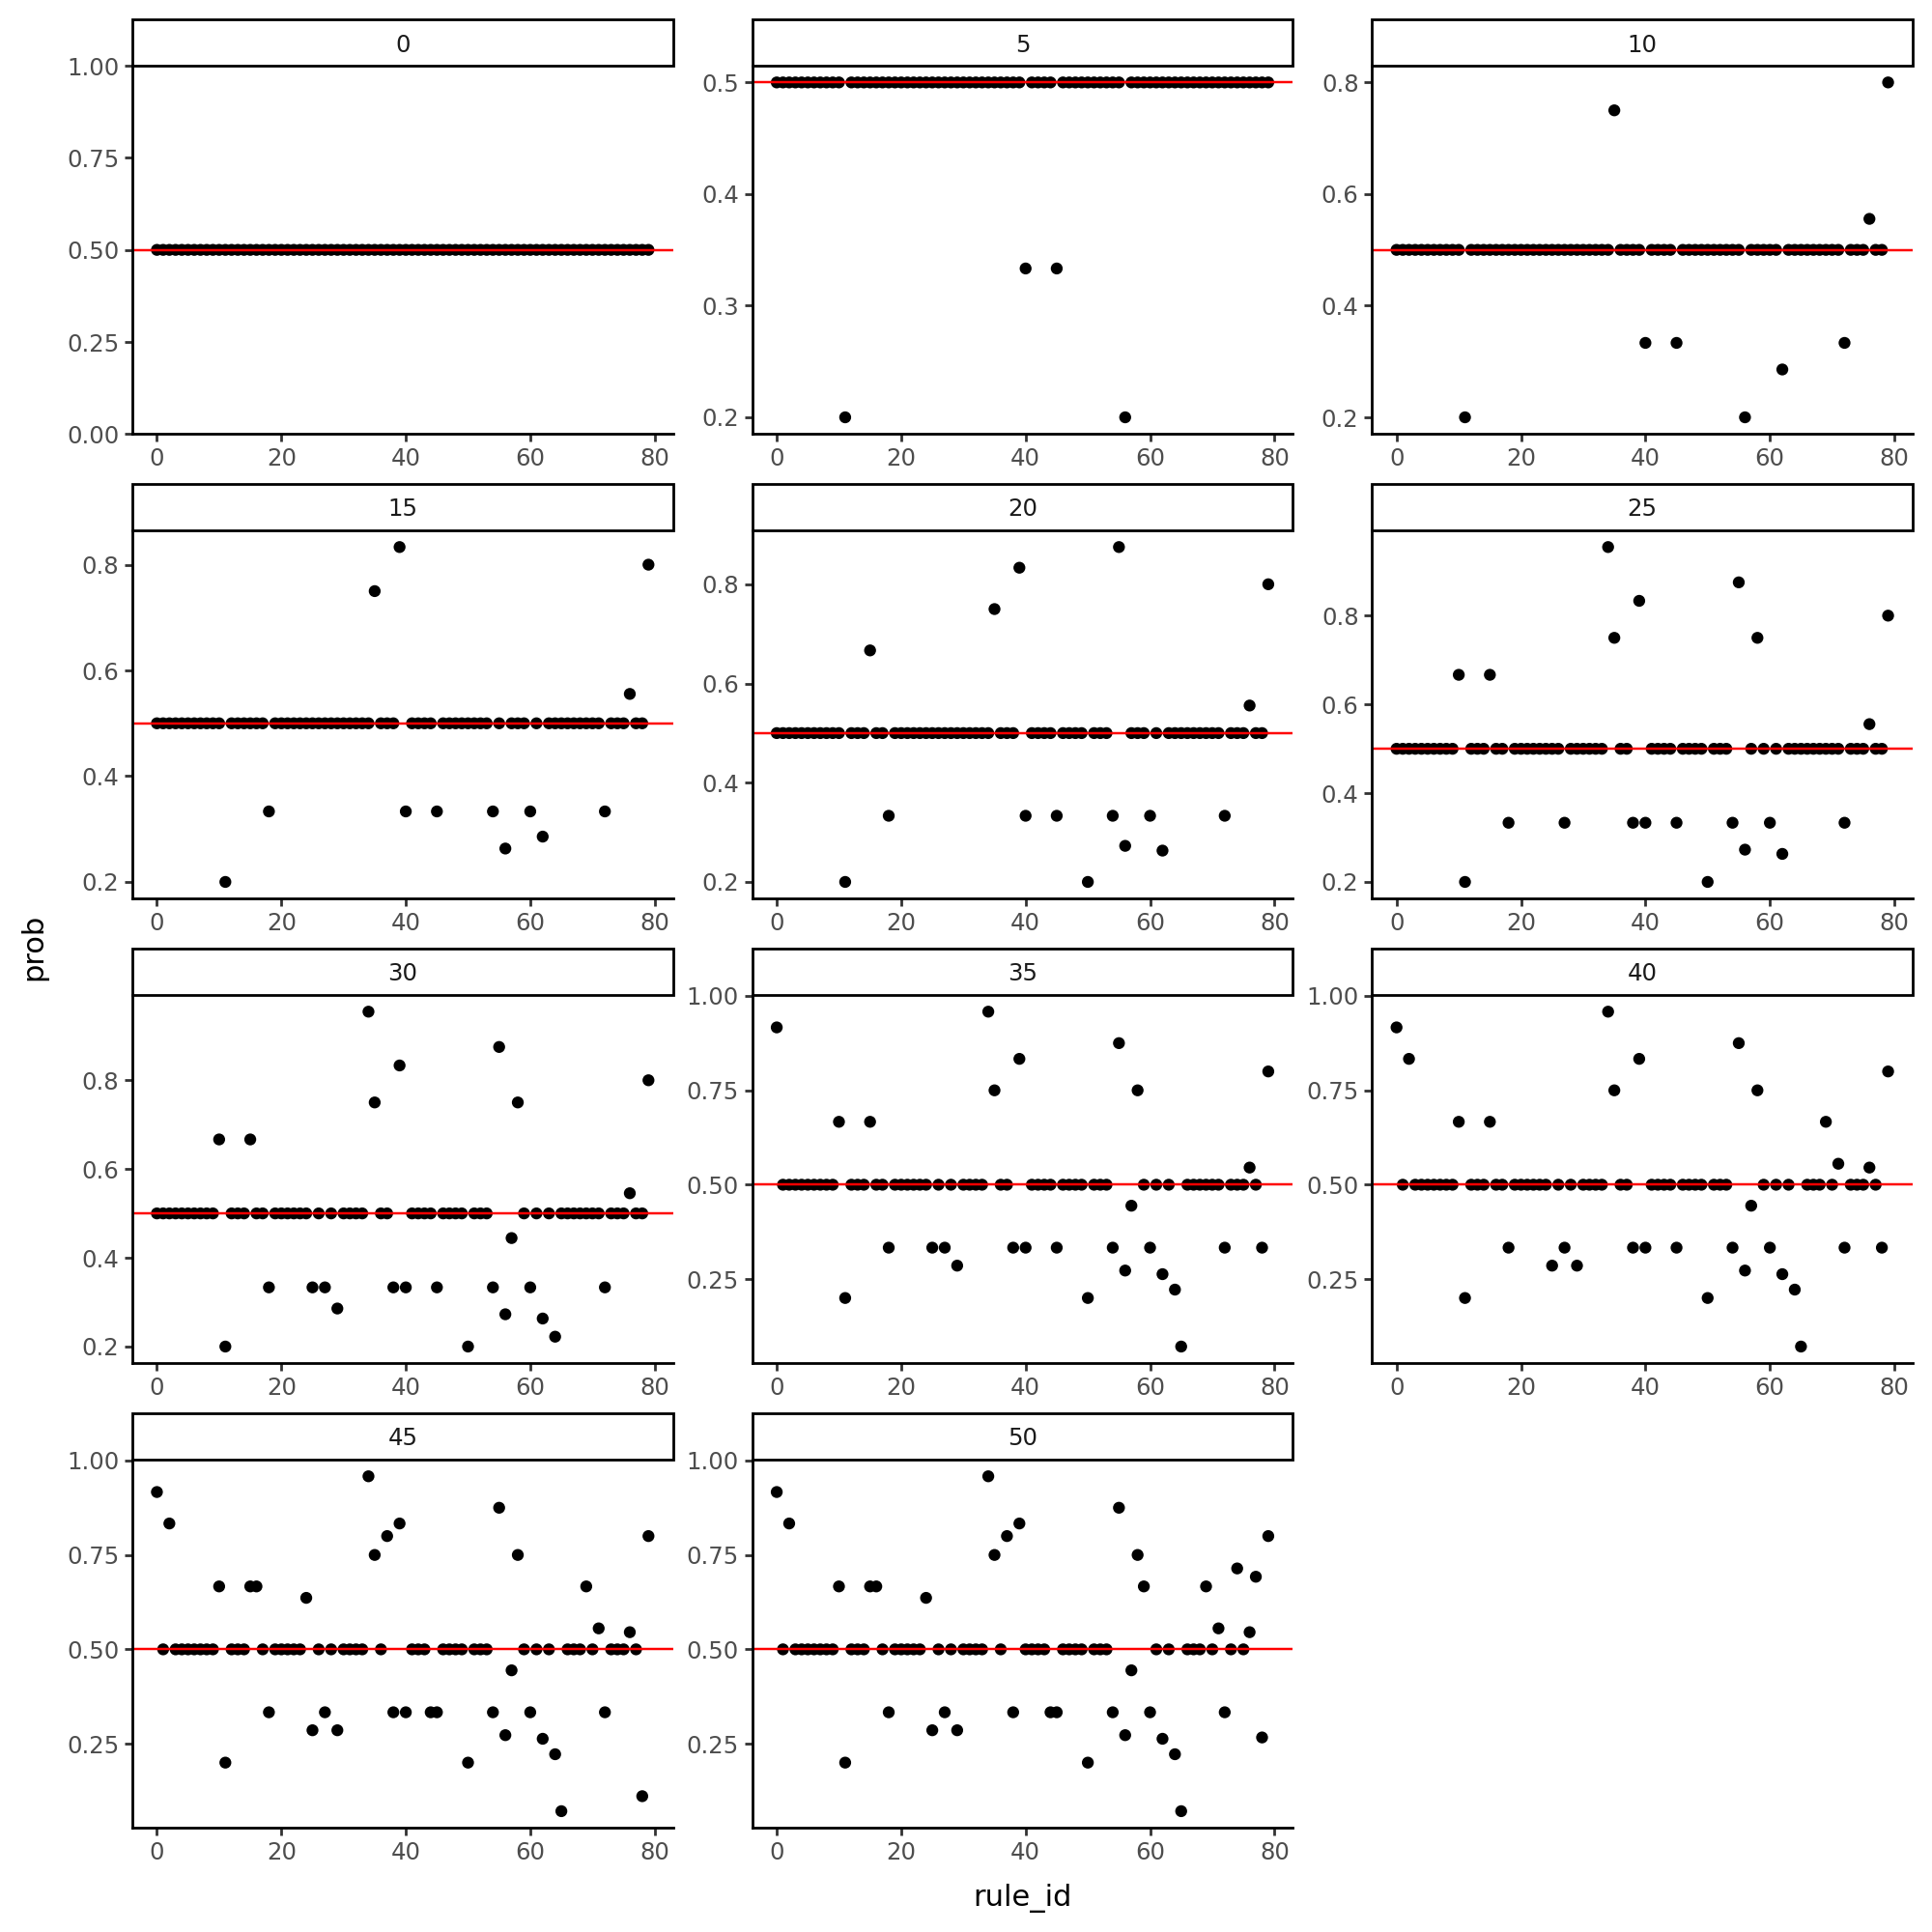

In [835]:
p1

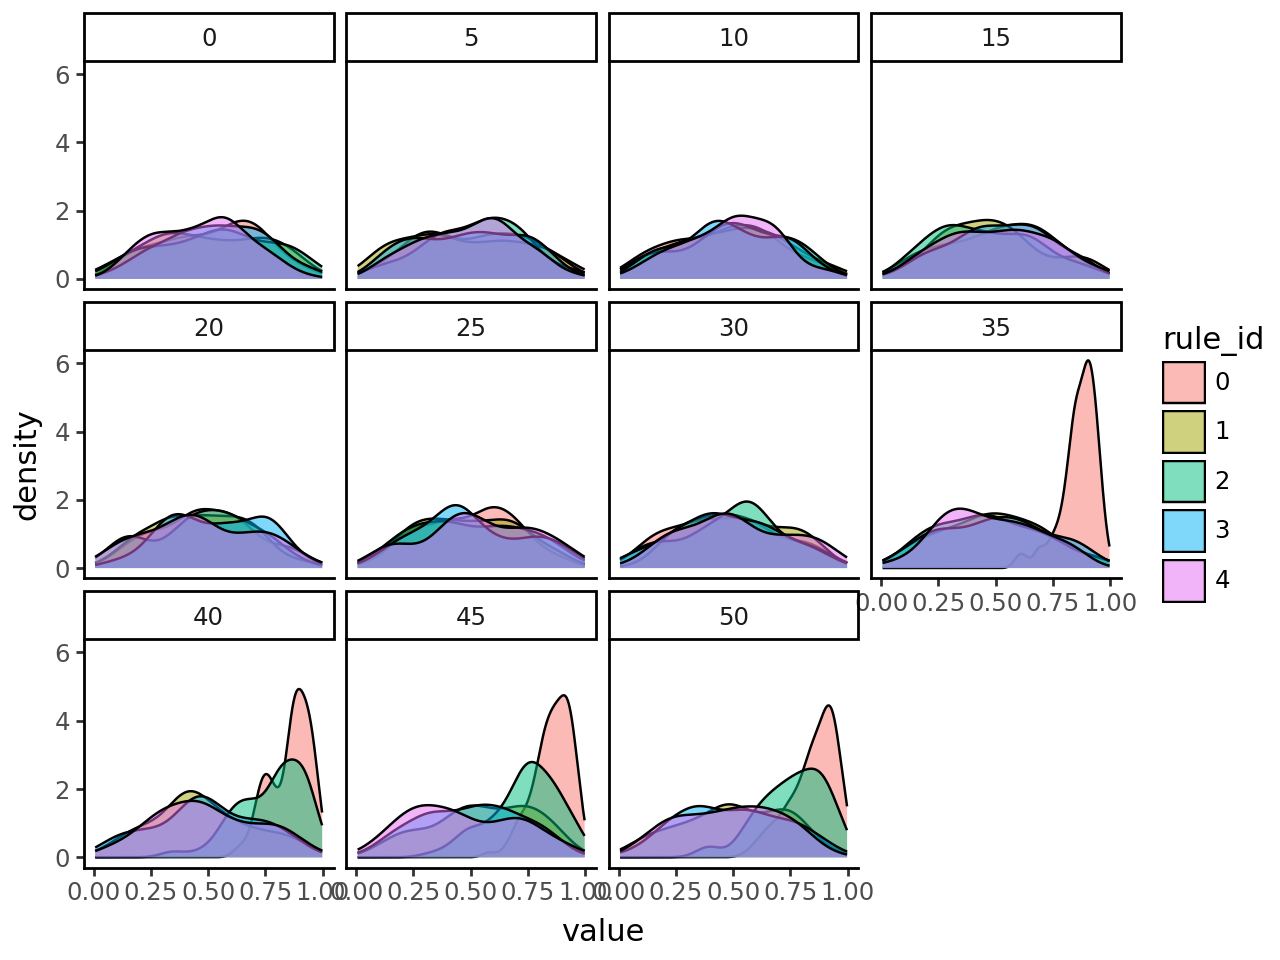

In [836]:
p2

In [ ]:
#now dynamic resampling?
#the same at max capacity

In [847]:
#set sampling intervals
#filter for only 3dim rules
rule_ds = Dataset.from_parquet("rules.parquet")
ag_rules = rule_ds.filter(dim_3_filter)
#add ids
ag_rules = ag_rules.add_column("rule_id",[i for i in range(80)])
true_rule = 'Thick_Legs and ( Arms_Down or Blue )'
n_t = 50
r = Rule(true_rule)
r.formalize_rule()

#set vars
memory = 80
#resampling interval
rs_turns = 1

#init --> set weights to 1
ag_rules =ag_rules.map(set_beta_priors,fn_kwargs={"bp":[2,2]})
for i in range(n_t):
    #get random stimuli
    stim = stimuli_maker()
    true_result = r.check_stimuli(stim)
    #only check n memory rules, change every x turns
    max_id = len(ag_rules["rule_id"])-1
    if i%rs_turns==0:
        ids_to_update = [random.randint(0,max_id) for i in range(memory)]
    else: 
        pass

    #resample the ids based on probs
    #all_betas for that id
    ab = np.array(ag_rules.filter(lambda ds: ds["rule_id"] in ids_to_update)["beta"])
    #keep only the last betas
    ab = ab[:,-1]
    res_ids = list(select_ids_on_p(ids_to_update,ab))

    #all rules that aggree get + all rules that disagree get -
    ag_rules = ag_rules.map(rrp_beta_mem_BPF, fn_kwargs={"passed":true_result,
     "stim":stim,
     "id_list":res_ids})
    
p1, p2 = make_plots(ag_rules)

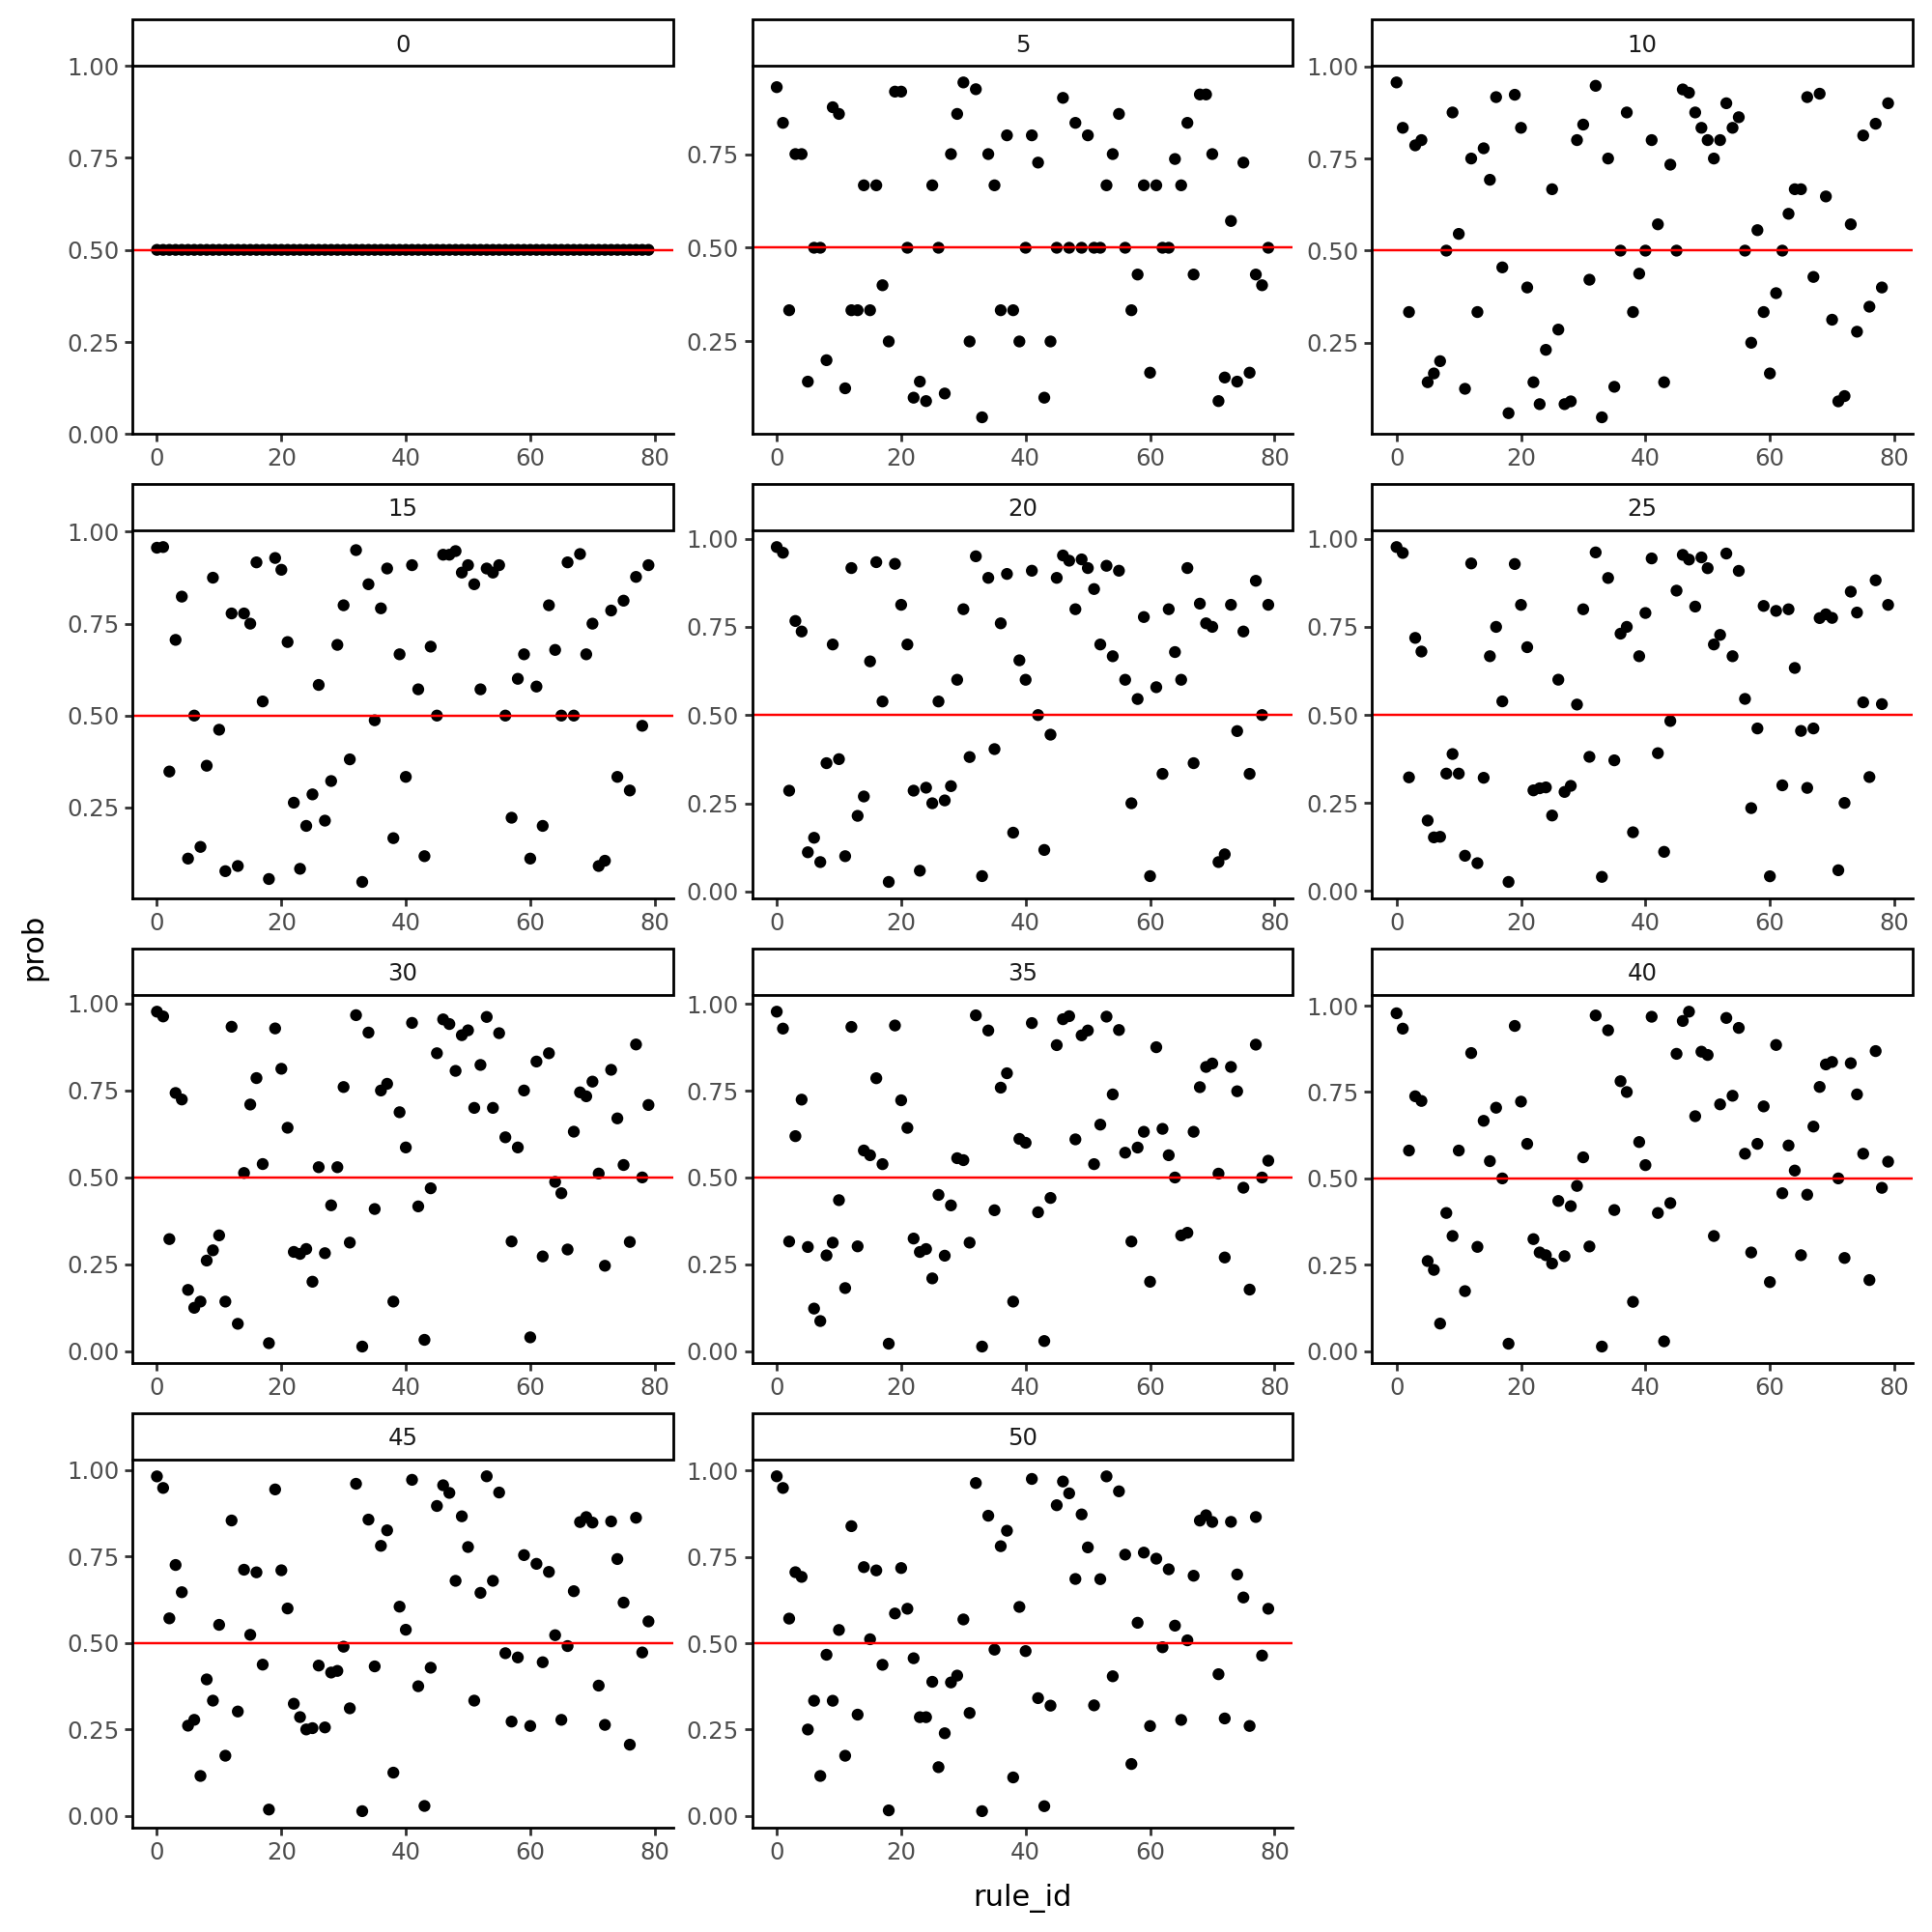

In [848]:
p1

In [ ]:
#3

In [ ]:
#problems 
#ok, but how does someone select the n memory rules ?
#ok, but how and when do they resample ?

In [ ]:
#answer 1 -> rules are not random!!!
#you only select one exact rule you test, but make updates on "nearby" rules similarly to gcm but instead of feature distance there is rule distance!

#look at feature based similarities
#+1 for same position "labec" +1 for same choice
# max is 6 (self) 

In [ ]:
#"labec"
#Thick_Legs and ( Arms_Down or Blue )

# val 1 at feature pos 0
# val 0 at feature pos 1
# val 0 at feature pos 4

#'Thick_Legs and ( Arms_Down or Blue )' Lac
#'Arms_Down and ( Spots or Eyes_With_Stalk )' aBE

np.str_('Thick_Legs and ( Arms_Down or Blue )')

In [941]:
def translate_rule_rev(rule:str):
    #split the full written rule to a list of words
    rule = str(rule).split()

    rule_map = { "l": "Thin_Legs",
             "L": "Thick_Legs",
             "a": "Arms_Down",
             "A":"Arms_Up",
             "b": "No_Spots",
             "B": "Spots",
             "e": "Eyes_Without_Stalk",
             "E": "Eyes_With_Stalk",
             "c": "Blue",
             "C": "Green"}
    #switch kw pairs
    rule_map = {v: k for k, v in rule_map.items()}
    #remove symbols and operators
    rule = [i for i in rule if i in rule_map.keys()]
    translated_l = []
    for i in rule:
        translated_l.append(rule_map.get(i))
    translated_l = "".join(translated_l)
        
    return translated_l

In [964]:
#calc dist

labec_codes = [translate_rule_rev(i) for i in list(ag_rules["rule"])]

test = np.array([labec_codes,labec_codes])
#1 translate to labec
#2 find sim
#sum(["aBE".count(i) for i in "Lac"])

In [999]:
def find_sim(a,b):
    """ find similarity +1 for common feature dimension +1 for common exact feature"""
    s = np.sum(np.array([a.count(i) for i in b]) + np.array([a.lower().count(i) for i in b.lower()]))
    return s


In [1000]:
dists= np.zeros(shape=(80, 80))
for idx_i ,i in enumerate(labec_codes):
    for idx_j, j in enumerate(labec_codes):
        sim = find_sim(i,j)
        dists[idx_i][idx_j] = sim

In [1004]:
#now look at the stimulus they let through
passes = [i for i in list(ag_rules["passes"])]

In [1027]:
def translate_rule_stim(stim:list[int]):
    """ labec codes stimuli"""
    rule_map = [{"l":0,"L":1},
                        {"a":0,"A":1},
                        {"b":0,"B":1},
                        {"e":0,"E":1},
                        {"c":0,"C":1}
    ]

    rule_map = [{v: k for k, v in i.items()} for i in rule_map]
    labec_code = []
    for stim_dim, stim_val in enumerate(stim):
        labec_code.append(rule_map[stim_dim].get(stim_val))
    labec_code = "".join(labec_code)
    return labec_code


        

In [1094]:
labec_passes = np.empty(shape=(80, 12),dtype="S16")

for r_id, r in enumerate(passes):
    for p_id, p in enumerate(r):
        labec_passes[r_id][p_id] = translate_rule_stim(p)

In [1105]:
dists_2= np.zeros(shape=(80, 80))
for idx_i ,i in enumerate(labec_passes):
    for idx_j, j in enumerate(labec_passes):
        sim = len(set(i).intersection(set(j)))
        dists_2[idx_i][idx_j] = sim

In [1164]:
test = []
for i  in range(80):
    for j in range(80): 
        #temp = {"ids":i,"id_2":j,"d":dists_2[i][j]}
        temp = {"ids":(i,j),"d":dists_2[i][j]}
        test.append(temp)


In [1183]:
sets = [set(i["ids"]) for i in test]

In [1196]:
# using dictionary to check for duplicates
hash_dict = {}
res = []
non_dup_ids = []
for id_set, s in enumerate(sets):
    if frozenset(s) in hash_dict:
        # set already exists in dictionary, so it is a duplicate
        res.append(s)
    else:
        # add set to dictionary
        hash_dict[frozenset(s)] = 1
        non_dup_ids.append(id_set)

# printing result
print("Duplicate sets list : " + str(res))

Duplicate sets list : [{0, 1}, {0, 2}, {1, 2}, {0, 3}, {1, 3}, {2, 3}, {0, 4}, {1, 4}, {2, 4}, {3, 4}, {0, 5}, {1, 5}, {2, 5}, {3, 5}, {4, 5}, {0, 6}, {1, 6}, {2, 6}, {3, 6}, {4, 6}, {5, 6}, {0, 7}, {1, 7}, {2, 7}, {3, 7}, {4, 7}, {5, 7}, {6, 7}, {8, 0}, {8, 1}, {8, 2}, {8, 3}, {8, 4}, {8, 5}, {8, 6}, {8, 7}, {0, 9}, {9, 1}, {9, 2}, {9, 3}, {9, 4}, {9, 5}, {9, 6}, {9, 7}, {8, 9}, {0, 10}, {1, 10}, {10, 2}, {10, 3}, {10, 4}, {10, 5}, {10, 6}, {10, 7}, {8, 10}, {9, 10}, {0, 11}, {1, 11}, {2, 11}, {3, 11}, {11, 4}, {11, 5}, {11, 6}, {11, 7}, {8, 11}, {9, 11}, {10, 11}, {0, 12}, {1, 12}, {2, 12}, {3, 12}, {12, 4}, {12, 5}, {12, 6}, {12, 7}, {8, 12}, {9, 12}, {10, 12}, {11, 12}, {0, 13}, {1, 13}, {2, 13}, {3, 13}, {4, 13}, {5, 13}, {13, 6}, {13, 7}, {8, 13}, {9, 13}, {10, 13}, {11, 13}, {12, 13}, {0, 14}, {1, 14}, {2, 14}, {3, 14}, {4, 14}, {5, 14}, {14, 6}, {14, 7}, {8, 14}, {9, 14}, {10, 14}, {11, 14}, {12, 14}, {13, 14}, {0, 15}, {1, 15}, {2, 15}, {3, 15}, {4, 15}, {5, 15}, {6, 15}, {7, 

In [1218]:
s = [test[i] for i in non_dup_ids]

In [1227]:
dists_2[0]

array([12.,  6.,  5.,  8.,  8.,  0.,  8.,  0.,  4.,  2.,  4.,  2.,  4.,
        0.,  9.,  0.,  4.,  0.,  0.,  6.,  8.,  6.,  0.,  0.,  3.,  5.,
        0.,  0.,  0.,  0.,  3.,  0., 10.,  2.,  9.,  6.,  8.,  8.,  0.,
        6.,  0., 10.,  0.,  0.,  0.,  8., 10., 10.,  9., 10.,  6.,  0.,
        5., 10.,  4., 10.,  0.,  4.,  9.,  6.,  4.,  8.,  3.,  5.,  0.,
        0., 10.,  4.,  8.,  6.,  6.,  2.,  0.,  6.,  6.,  8.,  3.,  6.,
        0.,  8.])

In [1231]:
dists[0]

array([6., 2., 2., 3., 3., 3., 3., 2., 3., 2., 1., 2., 1., 2., 2., 3., 3.,
       2., 2., 4., 3., 2., 1., 1., 1., 2., 1., 4., 3., 3., 1., 2., 4., 2.,
       2., 4., 4., 3., 1., 3., 2., 4., 3., 2., 3., 3., 4., 4., 2., 4., 2.,
       3., 2., 4., 3., 4., 3., 3., 2., 3., 1., 5., 1., 2., 4., 5., 4., 1.,
       3., 4., 2., 2., 3., 3., 3., 3., 1., 4., 2., 5.])

In [1241]:
n_df = []
for idx_i, i in enumerate(ag_rules):
    i["dists"] = dists[idx_i]
    n_df.append(i)

n_df = Dataset.from_list(n_df)

In [1251]:
n_df[0]["dists"]

[6.0,
 2.0,
 2.0,
 3.0,
 3.0,
 3.0,
 3.0,
 2.0,
 3.0,
 2.0,
 1.0,
 2.0,
 1.0,
 2.0,
 2.0,
 3.0,
 3.0,
 2.0,
 2.0,
 4.0,
 3.0,
 2.0,
 1.0,
 1.0,
 1.0,
 2.0,
 1.0,
 4.0,
 3.0,
 3.0,
 1.0,
 2.0,
 4.0,
 2.0,
 2.0,
 4.0,
 4.0,
 3.0,
 1.0,
 3.0,
 2.0,
 4.0,
 3.0,
 2.0,
 3.0,
 3.0,
 4.0,
 4.0,
 2.0,
 4.0,
 2.0,
 3.0,
 2.0,
 4.0,
 3.0,
 4.0,
 3.0,
 3.0,
 2.0,
 3.0,
 1.0,
 5.0,
 1.0,
 2.0,
 4.0,
 5.0,
 4.0,
 1.0,
 3.0,
 4.0,
 2.0,
 2.0,
 3.0,
 3.0,
 3.0,
 3.0,
 1.0,
 4.0,
 2.0,
 5.0]

In [ ]:
#so first, out of all ps -> select 1 rule

#then out all dists, select x based on similarity?
#if I keep itself in it, does it remove the need to the BPF

In [ ]:
#relative ps instead of global?
#globals are harder ro arhue, cus "How" fo they stay fixed, not impossible though humans have priors without consciously thinking about them all the time

#relative, after sampling non sampled ones always return to flat
#sample x with dups possible based on dists